# This notebook is a major part of the LASSO updraft width resolution sensitivity paper
## It makes the following plots:
- Number of narrow vs wide cells by case date
- Composite profiles (above cloud base) of updraft diameter, buoyancy, W, mass flux, shell RH
- Pre-CI environments surrounding CI location for the deepest group of wide cells

In [1]:
import os, sys
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
from matplotlib.font_manager import FontProperties
import pandas as pd
from sklearn.neighbors import KernelDensity
import warnings

In [2]:
xr.__version__

'2024.2.0'

## Load Pre-filtered Combined Datasets

This notebook loads the pre-filtered combined datasets generated by the `filter_and_save_combined_tracks.py` script, which combines and filters cell tracking data from multiple LASSO case dates.

In [3]:
# Configuration
# Figure output directory
# figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell/'
# figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_test/'
figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/'
os.makedirs(figdir, exist_ok=True)

# Input directory for pre-filtered combined datasets
input_dir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/cell_stats_combined'

# Time resolution [minutes]
time_res = 5.0

# Domain 4 boundaries (used for filtering)
lon_range = [-65., -63.3]
lat_range = [-33., -30.8]
lifetime_range = [15, 1000]  # [minutes]

# Time for representative environment
# time_env = -1

In [4]:
# Load pre-filtered datasets directly into memory (avoid Dask for faster operations)
print("Loading pre-filtered combined datasets into memory...")

# Load D2 (2.5 km domain) - load() loads into memory immediately
file_d2 = f'{input_dir}/stats_combined_filtered_d2.nc'
print(f"Loading: {file_d2}")
dsnms_d2 = xr.open_dataset(file_d2).load()  # .load() brings all data into memory
ntracks_nms_d2 = dsnms_d2.sizes['tracks']
print(f"  D2 filtered tracks: {ntracks_nms_d2}")

# Load D3 domain
file_d3 = f'{input_dir}/stats_combined_filtered_d3_5min_2.5km.nc'
print(f"Loading: {file_d3}")
dsnms_d3 = xr.open_dataset(file_d3).load()
ntracks_nms_d3 = dsnms_d3.sizes['tracks']
print(f"  D3 filtered tracks: {ntracks_nms_d3}")

# Load D4 domain
file_d4 = f'{input_dir}/stats_combined_filtered_d4_5min_2.5km.nc'
print(f"Loading: {file_d4}")
dsnms_d4 = xr.open_dataset(file_d4).load()
ntracks_nms_d4 = dsnms_d4.sizes['tracks']
print(f"  D4 filtered tracks: {ntracks_nms_d4}")

print("\nAll datasets loaded into memory successfully!")
print(f"Total filtered tracks: {ntracks_nms_d2 + ntracks_nms_d3 + ntracks_nms_d4}")

# Display memory usage
mem_d2 = sum(var.nbytes for var in dsnms_d2.variables.values()) / 1e9
mem_d3 = sum(var.nbytes for var in dsnms_d3.variables.values()) / 1e9
mem_d4 = sum(var.nbytes for var in dsnms_d4.variables.values()) / 1e9
print(f"\nMemory usage:")
print(f"  D2: {mem_d2:.2f} GB")
print(f"  D3: {mem_d3:.2f} GB")
print(f"  D4: {mem_d4:.2f} GB")
print(f"  Total: {mem_d2 + mem_d3 + mem_d4:.2f} GB")

Loading pre-filtered combined datasets into memory...
Loading: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/cell_stats_combined/stats_combined_filtered_d2.nc
  D2 filtered tracks: 646
Loading: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/cell_stats_combined/stats_combined_filtered_d3_5min_2.5km.nc
  D3 filtered tracks: 830
Loading: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/cell_stats_combined/stats_combined_filtered_d4_5min_2.5km.nc
  D4 filtered tracks: 968

All datasets loaded into memory successfully!
Total filtered tracks: 2444

Memory usage:
  D2: 0.50 GB
  D3: 0.64 GB
  D4: 0.75 GB
  Total: 1.89 GB


In [5]:
# Extract common variables from datasets
# Time coordinate [minutes]
xtime = dsnms_d2.times * time_res

# Modify the first two times (pre-CI) time values (unit: minutes)
# This is hardcoded specific to the average environments files where the extracted time frequencies are 15 min
# Refer to config files: config_lasso_wrf*.yml
# - minutes_prior: 30
# - freq_prior: 15
# xtime.isel(times=slice(0,3))[:] = [-30., -15., 0.]

# Height coordinates
height = dsnms_d2.height  # Environmental variables height
height_core = dsnms_d2.z  # Updraft variables height

# Time window for CI
time_window = (dsnms_d2.attrs['time_start'], dsnms_d2.attrs['time_end'])

print(f"Time coordinate (xtime): {xtime.min().values} to {xtime.max().values} minutes")
print(f"Time window for CI: {time_window} minutes")
print(f"Height levels (environment): {len(height)} levels")
print(f"Height levels (core): {len(height_core)} levels")

Time coordinate (xtime): 0.0 to 995.0 minutes
Time window for CI: (0, 60) minutes
Height levels (environment): 101 levels
Height levels (core): 40 levels


In [6]:
# Display dataset dimensions and summary
print("D2 Dataset:")
print(dsnms_d2)
print("\nD3 Dataset:")
print(dsnms_d3)
print("\nD4 Dataset:")
print(dsnms_d4)

D2 Dataset:
<xarray.Dataset> Size: 499MB
Dimensions:                  (tracks: 646, height: 101, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 5kB 0 1 2 5 ... 1222 1224 1226 1227
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
  * height                   (height) float64 808B 0.0 200.0 ... 1.98e+04 2e+04
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
    core                     int64 8B 0
Data variables: (12/195)
    temperature              (tracks, height) float32 261kB nan nan ... 208.3
    qv                       (tracks, height) float32 261kB nan nan ... 2.72e-06
    rh                       (tracks, height) float32 261kB nan nan ... 2.431
    pressure                 (tracks, height) float32 261kB nan ... 5.583e+03
    u                        (tracks, height) float32 261kB nan nan ... 0.8557
    v                        (tracks, height) float32 261kB nan nan ... 0.2294
    ...         

## Check number of merge after time_window tracks

In [7]:
# Tracks where merging occurs after the time_window
lifetime_merge_after_d2 = dsnms_d2.track_duration.where(~np.isnan(dsnms_d2.end_merge_cloudnumber), drop=True) * time_res
minlifetime_merge_after_d2 = lifetime_merge_after_d2.min().values
ntracks_merge_after_d2 = (lifetime_merge_after_d2).sizes['tracks']
print(f'D2 merge after time_window tracks: {ntracks_merge_after_d2}, min lifetime: {minlifetime_merge_after_d2} min')

# Tracks where merging occurs after the time_window
lifetime_merge_after_d3 = dsnms_d3.track_duration.where(~np.isnan(dsnms_d3.end_merge_cloudnumber), drop=True) * time_res
minlifetime_merge_after_d3 = lifetime_merge_after_d3.min().values
ntracks_merge_after_d3 = (lifetime_merge_after_d3).sizes['tracks']
print(f'D3 merge after time_window tracks: {ntracks_merge_after_d3}, min lifetime: {minlifetime_merge_after_d3} min')

# Tracks where merging occurs after the time_window
lifetime_merge_after_d4 = dsnms_d4.track_duration.where(~np.isnan(dsnms_d4.end_merge_cloudnumber), drop=True) * time_res
minlifetime_merge_after_d4 = lifetime_merge_after_d4.min().values
ntracks_merge_after_d4 = (lifetime_merge_after_d4).sizes['tracks']
print(f'D4 merge after time_window tracks: {ntracks_merge_after_d4}, min lifetime: {minlifetime_merge_after_d4} min')

D2 merge after time_window tracks: 83, min lifetime: 65.0 min
D3 merge after time_window tracks: 82, min lifetime: 65.0 min
D4 merge after time_window tracks: 77, min lifetime: 65.0 min


### Convert MU LPL from HAGL to HAMSL and add it back to the DataSets

In [8]:
# Convert MU parcel height from AGL to MSL
mu_parcel_ht_msl_d2 = dsnms_d2.initial_ht_parcel_mu + dsnms_d2.Z_surface
mu_parcel_ht_msl_d3 = dsnms_d3.initial_ht_parcel_mu + dsnms_d3.Z_surface
mu_parcel_ht_msl_d4 = dsnms_d4.initial_ht_parcel_mu + dsnms_d4.Z_surface

mu_parcel_ht_msl_d2.attrs = {
    'long_name': 'Height above MSL of the MU parcel origin',
    'units': 'm',
}
mu_parcel_ht_msl_d3.attrs = {
    'long_name': 'Height above MSL of the MU parcel origin',
    'units': 'm',
}
mu_parcel_ht_msl_d4.attrs = {
    'long_name': 'Height above MSL of the MU parcel origin',
    'units': 'm',
}
# Add to DataSet
dsnms_d2['mu_parcel_ht_msl'] = mu_parcel_ht_msl_d2
dsnms_d3['mu_parcel_ht_msl'] = mu_parcel_ht_msl_d3
dsnms_d4['mu_parcel_ht_msl'] = mu_parcel_ht_msl_d4

(array([ 48.,  43.,  78.,  67.,  76., 101.,  53.,  93.,  54.,  33.]),
 array([ 189.53134,  369.82443,  550.1175 ,  730.4106 ,  910.7037 ,
        1090.9967 , 1271.2898 , 1451.5829 , 1631.876  , 1812.1691 ,
        1992.4622 ], dtype=float32),
 <BarContainer object of 10 artists>)

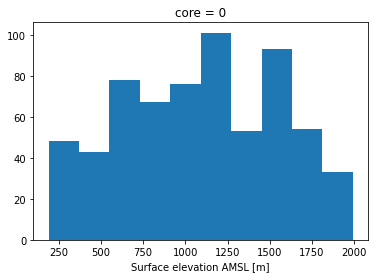

In [9]:
dsnms_d2.Z_surface.plot.hist()

## Subset cell area/ETH stats to **CI time window** and get their CI-period max values

In [10]:
xtime, time_window

(<xarray.DataArray 'times' (times: 200)> Size: 2kB
 array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
         55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
        110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160.,
        165., 170., 175., 180., 185., 190., 195., 200., 205., 210., 215.,
        220., 225., 230., 235., 240., 245., 250., 255., 260., 265., 270.,
        275., 280., 285., 290., 295., 300., 305., 310., 315., 320., 325.,
        330., 335., 340., 345., 350., 355., 360., 365., 370., 375., 380.,
        385., 390., 395., 400., 405., 410., 415., 420., 425., 430., 435.,
        440., 445., 450., 455., 460., 465., 470., 475., 480., 485., 490.,
        495., 500., 505., 510., 515., 520., 525., 530., 535., 540., 545.,
        550., 555., 560., 565., 570., 575., 580., 585., 590., 595., 600.,
        605., 610., 615., 620., 625., 630., 635., 640., 645., 650., 655.,
        660., 665., 670., 675., 680., 685., 690., 695., 700.,

In [11]:
# Find time coordinate index of the time_window
tidx_start = np.abs(xtime - np.min(time_window)).argmin().item()
tidx_end = np.abs(xtime - np.max(time_window)).argmin().item()
print(f"CI time window start index: {tidx_start}, end index: {tidx_end}")

CI time window start index: 0, end index: 12


In [12]:
# Subset DataSet to CI time_window
dsCI_d2 = dsnms_d2.isel(times=slice(tidx_start, tidx_end))
dsCI_d3 = dsnms_d3.isel(times=slice(tidx_start, tidx_end))
dsCI_d4 = dsnms_d4.isel(times=slice(tidx_start, tidx_end))

# Cell max reflectivity
maxdbz_d2 = dsCI_d2['max_dbz'].load()
maxdbz_d3 = dsCI_d3['max_dbz'].load()
maxdbz_d4 = dsCI_d4['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d2 = dsCI_d2['maxETH_10dbz'].load()
maxETH_10dbz_d3 = dsCI_d3['maxETH_10dbz'].load()
maxETH_10dbz_d4 = dsCI_d4['maxETH_10dbz'].load()
# Cell diameter
cellarea_d2 = dsCI_d2['cell_area'].load()
cellarea_d3 = dsCI_d3['cell_area'].load()
cellarea_d4 = dsCI_d4['cell_area'].load()
celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)
# Max updraft top height
trackmaxWtop_d2 = dsCI_d2.Wtop.max(dim='times')
trackmaxWtop_d3 = dsCI_d3.Wtop.max(dim='times')
trackmaxWtop_d4 = dsCI_d4.Wtop.max(dim='times')
# Calculate max W diameter (Warea_max has no times dimension)
maxWdiam_d2 = 2*np.sqrt(dsCI_d2.Warea_max/np.pi)
maxWdiam_d3 = 2*np.sqrt(dsCI_d3.Warea_max/np.pi)
maxWdiam_d4 = 2*np.sqrt(dsCI_d4.Warea_max/np.pi)

## Get **CI-max** 10dBZ ETH and cell diameter percentile values

In [13]:
trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
trackmaxCellDiam_d2 = celldiam_d2.max(dim='times')
trackmaxdbz_d2 = maxdbz_d2.max(dim='times')

trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
trackmaxCellDiam_d3 = celldiam_d3.max(dim='times')
trackmaxdbz_d3 = maxdbz_d3.max(dim='times')

trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
trackmaxCellDiam_d4 = celldiam_d4.max(dim='times')
trackmaxdbz_d4 = maxdbz_d4.max(dim='times')

In [14]:
# Add CI-period variables to DataSet
dsnms_d2['CImaxCellDiam'] = trackmaxCellDiam_d2
dsnms_d2['CImaxETH_10dbz'] = trackmaxETH_10dbz_d2
dsnms_d2['CImaxdbz'] = trackmaxdbz_d2
dsnms_d2['CImaxWDiam'] = maxWdiam_d2

# Add CI-period variables to DataSet
dsnms_d3['CImaxCellDiam'] = trackmaxCellDiam_d3
dsnms_d3['CImaxETH_10dbz'] = trackmaxETH_10dbz_d3
dsnms_d3['CImaxdbz'] = trackmaxdbz_d3
dsnms_d3['CImaxWDiam'] = maxWdiam_d3

# Add CI-period variables to DataSet
dsnms_d4['CImaxCellDiam'] = trackmaxCellDiam_d4
dsnms_d4['CImaxETH_10dbz'] = trackmaxETH_10dbz_d4
dsnms_d4['CImaxdbz'] = trackmaxdbz_d4
dsnms_d4['CImaxWDiam'] = maxWdiam_d4

## Separate narrow vs. wide cell DataSets
#### Thresholds determined in `plot_track_correlations_lasso_by_celldiam_avg_env_load_filtered.ipynb.ipynb`

In [15]:
# Original thresholds at native resolutions
# narrow_diam_d2 = 12.62  # km
# narrow_diam_d3 = 7.36  # km
# narrow_diam_d4 = 7.33  # km

# wide_diam_d2 = 15.71  # km
# wide_diam_d3 = 8.65  # km
# wide_diam_d4 = 8.80 # km

# # Same thresholds for D2, D3, D4
# narrow_diam_d2 = 12.62  # km
# narrow_diam_d3 = 12.62  # km
# narrow_diam_d4 = 12.62  # km

# wide_diam_d2 = 15.71  # km
# wide_diam_d3 = 15.71  # km
# wide_diam_d4 = 15.71  # km

# Test
narrow_diam_d2 = 12.62  # km
narrow_diam_d3 = 12.93  # km
narrow_diam_d4 = 12.93  # km

wide_diam_d2 = 15.71  # km
wide_diam_d3 = 15.45  # km
wide_diam_d4 = 14.66  # km

In [16]:
# MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
MULNB_thresh = 6.0  # [km]
# Threshold for max distance between updraft base and LCL height [km]
max_Wbase_LCL_dist = 2.0  # [km]
# Threshold for updraft top fit line slope
min_Wtop_slope = 0

## Get preCI MU LNB

In [17]:
# Select preCI time, the drop the times coordinate (this avoids conflict with cell lifetime-max variables that has no times coordinate)
# Add surface elevation to convert LNB from HAMSL to HAGL
# MULNB_d2 = ((dsnms_d2.EL_height_mu + dsnms_d2.Z_surface).sel(times=time_env)/1000).reset_coords('times', drop=True)
# MULNB_d3 = ((dsnms_d3.EL_height_mu + dsnms_d3.Z_surface).sel(times=time_env)/1000).reset_coords('times', drop=True)
# MULNB_d4 = ((dsnms_d4.EL_height_mu + dsnms_d4.Z_surface).sel(times=time_env)/1000).reset_coords('times', drop=True)
# MULNB_d2 = ((dsnms_d2.EL_height_mu).sel(times=time_env)/1000).reset_coords('times', drop=True)
# MULNB_d3 = ((dsnms_d3.EL_height_mu).sel(times=time_env)/1000).reset_coords('times', drop=True)
# MULNB_d4 = ((dsnms_d4.EL_height_mu).sel(times=time_env)/1000).reset_coords('times', drop=True)

MULNB_d2 = (dsnms_d2.EL_height_mu/1000)
MULNB_d3 = (dsnms_d3.EL_height_mu/1000)
MULNB_d4 = (dsnms_d4.EL_height_mu/1000)

(array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.01042753, 0.01876955, 0.01459854, 0.02502607,
        0.02294056, 0.01459854, 0.01459854, 0.01459854, 0.02919708,
        0.08133472, 0.23357664, 0.17935349, 0.18978102, 0.05005214,
        0.00625652, 0.01876955, 0.0375391 , 0.07716371, 0.12095933,
        0.20229406, 0.16475495, 0.15641293, 0.13764338, 0.06465068,
        0.07090719, 0.04379562, 0.        , 0.        , 0.        ,
        0.        ]),
 array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
        11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ,
        16.5, 17. , 17.5, 18. ]),
 <BarContainer object of 36 artists>)

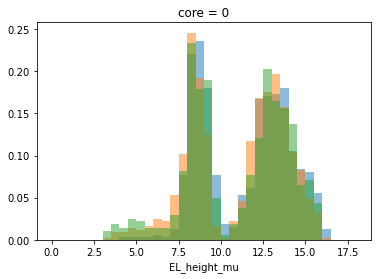

In [18]:
bins = np.arange(0, 18.1, 0.5)
MULNB_d2.plot.hist(bins=bins, alpha=0.5, label='D2', density=True)
MULNB_d3.plot.hist(bins=bins, alpha=0.5, label='D3', density=True)
MULNB_d4.plot.hist(bins=bins, alpha=0.5, label='D4', density=True)

In [19]:
# trackmaxCellDiam_d2.shape, dsnms_d2.CImaxCellDiam.shape, MULNB_d2.shape
narrow_diam_d2, wide_diam_d2, MULNB_thresh

(12.62, 15.71, 6.0)

In [20]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
# 3. Updraft base height close to LCL
# Note: With data in memory, no need for .compute() - operations are instant!
narrow_tracks_d2 = ((dsnms_d2.CImaxCellDiam < narrow_diam_d2) & (MULNB_d2 > MULNB_thresh) \
                    & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist))
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d2 = ((dsnms_d2.CImaxCellDiam >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh) \
                #   & (dsnms_d2.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist))
# Subset DataSets
ds_narrow_d2 = dsnms_d2.where(narrow_tracks_d2, drop=True)
ds_wide_d2 = dsnms_d2.where(wide_tracks_d2, drop=True)
ntracks_narrow_d2 = ds_narrow_d2.sizes['tracks']
ntracks_wide_d2 = ds_wide_d2.sizes['tracks']
print(f'Number of narrow cells (D2): {ntracks_narrow_d2}')
print(f'Number of wide cells (D2): {ntracks_wide_d2}')

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d2 = (ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d2 = (ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d2 = ds_narrow_d2.CImaxdbz
wide_maxdbz_d2 = ds_wide_d2.CImaxdbz
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d2 = ds_narrow_d2.CImaxETH_10dbz
wide_maxETH10dbz_d2 = ds_wide_d2.CImaxETH_10dbz
# CI-max cell diameter
narrow_maxdiam_d2 = ds_narrow_d2.CImaxCellDiam
wide_maxdiam_d2 = ds_wide_d2.CImaxCellDiam
# CI-window cloud-base updraft diameter
narrow_maxWdiam_d2 = ds_narrow_d2.CImaxWDiam
wide_maxWdiam_d2 = ds_wide_d2.CImaxWDiam
# CI-window cloud-base updraft speed
narrow_maxWspeed_d2 = ds_narrow_d2.Wspeed_max
wide_maxWspeed_d2 = ds_wide_d2.Wspeed_max

Number of narrow cells (D2): 401
Number of wide cells (D2): 89


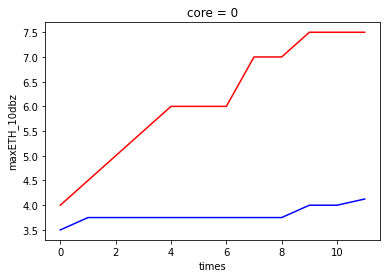

In [21]:
ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='b')
ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='r')

(array([ 0.,  0.,  0.,  1.,  0., 14.,  7., 12., 14., 13.,  8.,  3.,  6.,
         5.,  4.,  2.,  0.,  0.,  0.,  0.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20]),
 <BarContainer object of 20 artists>)

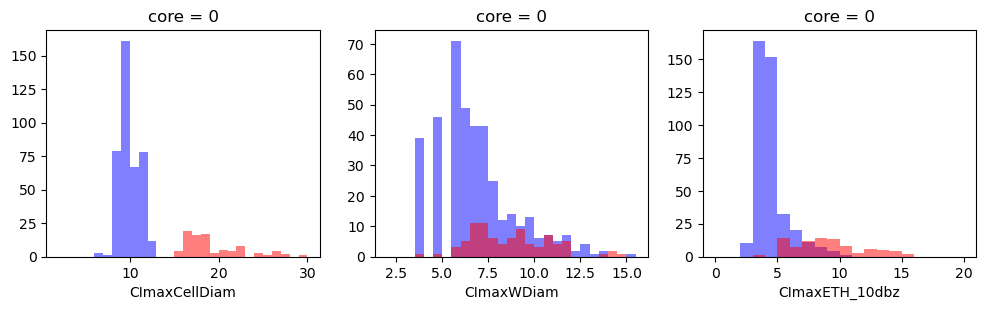

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(12,3), dpi=100)
ax0 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax0)
wide_maxdiam_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax0)
ax1 = axes[1]
bins = np.arange(2, 16, 0.5)
narrow_maxWdiam_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxWdiam_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[2]
bins = np.arange(0, 21, 1)
narrow_maxETH10dbz_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)

In [23]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
# 3. Updraft base height close to LCL
narrow_tracks_d3 = ((dsnms_d3.CImaxCellDiam < narrow_diam_d3) & (MULNB_d3 > MULNB_thresh) \
                    & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d3 = ((dsnms_d3.CImaxCellDiam >= wide_diam_d3) & (MULNB_d3 > MULNB_thresh) \
                #   & (dsnms_d3.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d3 = dsnms_d3.where(narrow_tracks_d3, drop=True)
ds_wide_d3 = dsnms_d3.where(wide_tracks_d3, drop=True)
ntracks_narrow_d3 = ds_narrow_d3.sizes['tracks']
ntracks_wide_d3 = ds_wide_d3.sizes['tracks']
print(f'Number of narrow cells (d3): {ntracks_narrow_d3}')
print(f'Number of wide cells (d3): {ntracks_wide_d3}')

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d3 = (ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d3 = (ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d3 = ds_narrow_d3.CImaxdbz
wide_maxdbz_d3 = ds_wide_d3.CImaxdbz
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d3 = ds_narrow_d3.CImaxETH_10dbz
wide_maxETH10dbz_d3 = ds_wide_d3.CImaxETH_10dbz
# CI-max cell diameter
narrow_maxdiam_d3 = ds_narrow_d3.CImaxCellDiam
wide_maxdiam_d3 = ds_wide_d3.CImaxCellDiam
# CI-window cloud-base updraft diameter
narrow_maxWdiam_d3 = ds_narrow_d3.CImaxWDiam
wide_maxWdiam_d3 = ds_wide_d3.CImaxWDiam
# CI-window cloud-base updraft speed
narrow_maxWspeed_d3 = ds_narrow_d3.Wspeed_max
wide_maxWspeed_d3 = ds_wide_d3.Wspeed_max

Number of narrow cells (d3): 379
Number of wide cells (d3): 83


(array([ 0.,  0.,  0.,  0.,  4., 11.,  6., 11., 11.,  8., 13., 10.,  3.,
         2.,  1.,  3.,  0.,  0.,  0.,  0.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20]),
 <BarContainer object of 20 artists>)

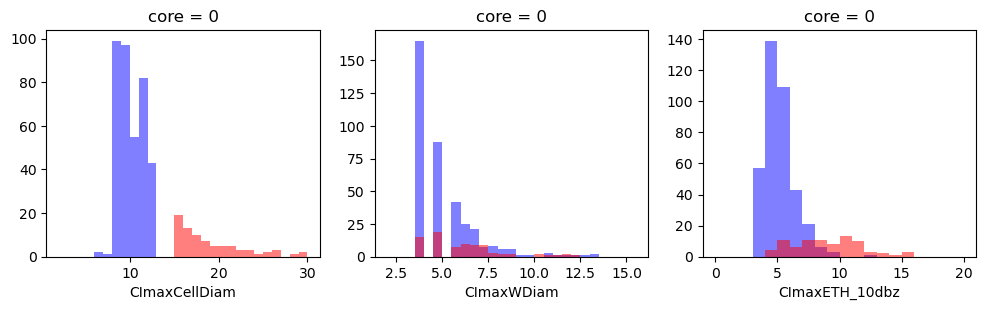

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12,3), dpi=100)
ax0 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax0)
wide_maxdiam_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax0)
ax1 = axes[1]
# bins = np.arange(0, 6, 0.2)
bins = np.arange(2, 16, 0.5)
narrow_maxWdiam_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxWdiam_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[2]
bins = np.arange(0, 21, 1)
narrow_maxETH10dbz_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)

In [25]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
# 3. Updraft base height close to LCL
narrow_tracks_d4 = ((dsnms_d4.CImaxCellDiam < narrow_diam_d4) & (MULNB_d4 > MULNB_thresh) \
                    & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d4 = ((dsnms_d4.CImaxCellDiam >= wide_diam_d4) & (MULNB_d4 > MULNB_thresh) \
                #   & (dsnms_d4.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d4 = dsnms_d4.where(narrow_tracks_d4, drop=True)
ds_wide_d4 = dsnms_d4.where(wide_tracks_d4, drop=True)
ntracks_narrow_d4 = ds_narrow_d4.sizes['tracks']
ntracks_wide_d4 = ds_wide_d4.sizes['tracks']
print(f'Number of narrow cells (d4): {ntracks_narrow_d4}')
print(f'Number of wide cells (d4): {ntracks_wide_d4}')

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d4 = (ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d4 = (ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d4 = ds_narrow_d4.CImaxdbz
wide_maxdbz_d4 = ds_wide_d4.CImaxdbz
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d4 = ds_narrow_d4.CImaxETH_10dbz
wide_maxETH10dbz_d4 = ds_wide_d4.CImaxETH_10dbz
# CI-max cell diameter
narrow_maxdiam_d4 = ds_narrow_d4.CImaxCellDiam
wide_maxdiam_d4 = ds_wide_d4.CImaxCellDiam
# CI-window cloud-base updraft diameter
narrow_maxWdiam_d4 = ds_narrow_d4.CImaxWDiam
wide_maxWdiam_d4 = ds_wide_d4.CImaxWDiam
# CI-window cloud-base updraft speed
narrow_maxWspeed_d4 = ds_narrow_d4.Wspeed_max
wide_maxWspeed_d4 = ds_wide_d4.Wspeed_max

Number of narrow cells (d4): 362
Number of wide cells (d4): 91


(array([ 0.,  0.,  4.,  3.,  7., 17., 16., 22.,  7.,  3.,  4.,  2.,  2.,
         2.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.]),
 array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]),
 <BarContainer object of 28 artists>)

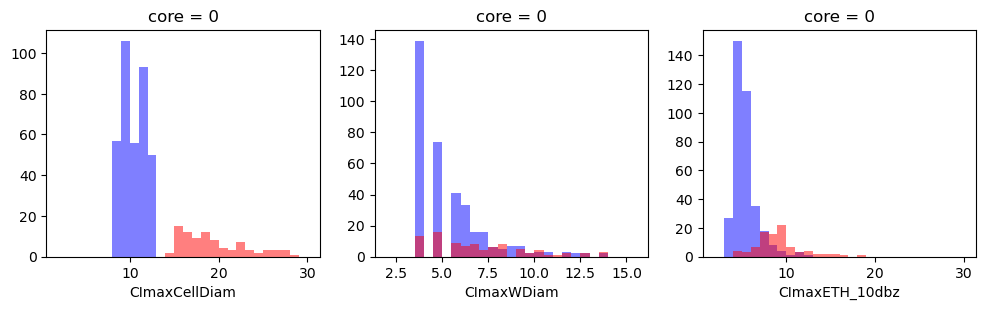

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(12,3), dpi=100)
ax0 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d4.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax0)
wide_maxdiam_d4.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax0)
ax1 = axes[1]
# bins = np.arange(0, 6, 0.2)
bins = np.arange(2, 16, 0.5)
narrow_maxWdiam_d4.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxWdiam_d4.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[2]
# bins = np.arange(0, 21, 1)
bins = np.arange(2, 31, 1)
narrow_maxETH10dbz_d4.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d4.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)

### D2 wide cell DataSet

In [27]:
wide_maxETH10dbz_d2.sizes, ds_wide_d2.sizes

(Frozen({'tracks': 89}),
 Frozen({'tracks': 89, 'height': 101, 'times': 200, 'z': 40}))

In [28]:
# Get median lifetime-max 10dBZ ETH as threshold to further separate shallow vs. deep cells
wide_maxETH10dbz_thresh_d2 = wide_maxETH10dbz_d2.median()
print(f'D2 wide cells 10-dBZ ETH median: {wide_maxETH10dbz_thresh_d2:.01f} km')

# Separate shallow & deep DataSets
ds_wide_deep_d2 = ds_wide_d2.where(wide_maxETH10dbz_d2 > wide_maxETH10dbz_thresh_d2, drop=True)
ds_wide_shallow_d2 = ds_wide_d2.where(wide_maxETH10dbz_d2 <= wide_maxETH10dbz_thresh_d2, drop=True)

# Get number of tracks
ntracks_wide_deep_d2 = ds_wide_deep_d2.sizes['tracks']
ntracks_wide_shallow_d2 = ds_wide_shallow_d2.sizes['tracks']
print(f'D2 number of wide & deep tracks: {ntracks_wide_deep_d2}')
print(f'D2 number of wide & shallow tracks: {ntracks_wide_shallow_d2}')

D2 wide cells 10-dBZ ETH median: 8.0 km
D2 number of wide & deep tracks: 41
D2 number of wide & shallow tracks: 48


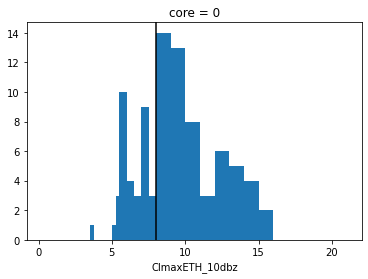

In [29]:
z_km = dsnms_d2.z/1000
wide_maxETH10dbz_d2.plot.hist(bins=z_km)
plt.axvline(wide_maxETH10dbz_thresh_d2, color='k')

### D2 narrow cell DataSet

In [30]:
# Get median lifetime-max 10dBZ ETH as threshold to further separate shallow vs. deep cells
narrow_maxETH10dbz_thresh_d2 = narrow_maxETH10dbz_d2.median()
print(f'D2 narrow cells 10-dBZ ETH median: {narrow_maxETH10dbz_thresh_d2:.01f} km')

# Separate shallow & deep DataSets
ds_narrow_deep_d2 = ds_narrow_d2.where(narrow_maxETH10dbz_d2 > narrow_maxETH10dbz_thresh_d2, drop=True)
ds_narrow_shallow_d2 = ds_narrow_d2.where(narrow_maxETH10dbz_d2 <= narrow_maxETH10dbz_thresh_d2, drop=True)

# Get number of tracks
ntracks_narrow_deep_d2 = ds_narrow_deep_d2.sizes['tracks']
ntracks_narrow_shallow_d2 = ds_narrow_shallow_d2.sizes['tracks']
print(f'D2 number of narrow & deep tracks: {ntracks_narrow_deep_d2}')
print(f'D2 number of narrow & shallow tracks: {ntracks_narrow_shallow_d2}')

D2 narrow cells 10-dBZ ETH median: 4.0 km


D2 number of narrow & deep tracks: 179
D2 number of narrow & shallow tracks: 222


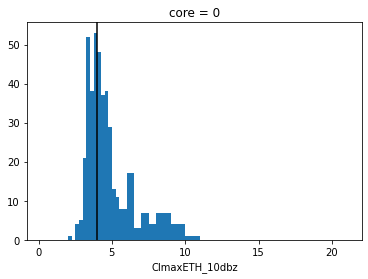

In [31]:
z_km = dsnms_d2.z/1000
narrow_maxETH10dbz_d2.plot.hist(bins=z_km)
plt.axvline(narrow_maxETH10dbz_thresh_d2, color='k')

(array([22., 26., 41.]),
 array([ 3.5,  7. ,  9. , 15. ]),
 <BarContainer object of 3 artists>)

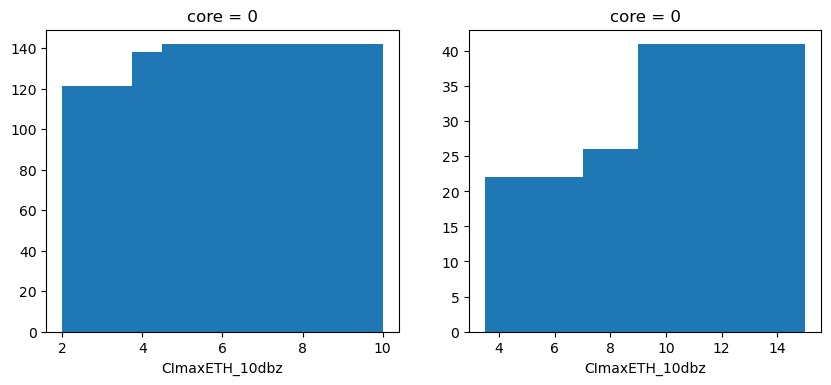

In [32]:
# Get quantile-based bin edges for ETH
nbins_ETH = 3
ETH_bins_n = np.quantile(narrow_maxETH10dbz_d2, np.linspace(0, 1, nbins_ETH + 1))
ETH_bins_w = np.quantile(wide_maxETH10dbz_d2, np.linspace(0, 1, nbins_ETH + 1))
# 
fig, axes = plt.subplots(1,2, figsize=(10,4), dpi=100)
narrow_maxETH10dbz_d2.plot.hist(bins=ETH_bins_n, ax=axes[0])
wide_maxETH10dbz_d2.plot.hist(bins=ETH_bins_w, ax=axes[1])

### D3 wide cell DataSet

In [33]:
# Get median lifetime-max 10dBZ ETH as threshold to further separate shallow vs. deep cells
wide_maxETH10dbz_thresh_d3 = wide_maxETH10dbz_d3.median()
print(f'd3 wide cells 10-dBZ ETH median: {wide_maxETH10dbz_thresh_d3:.01f} km')

# Separate shallow & deep DataSets
ds_wide_deep_d3 = ds_wide_d3.where(wide_maxETH10dbz_d3 >= wide_maxETH10dbz_thresh_d3, drop=True)
ds_wide_shallow_d3 = ds_wide_d3.where(wide_maxETH10dbz_d3 < wide_maxETH10dbz_thresh_d3, drop=True)

# Get number of tracks
ntracks_wide_deep_d3 = ds_wide_deep_d3.sizes['tracks']
ntracks_wide_shallow_d3 = ds_wide_shallow_d3.sizes['tracks']
print(f'D3 number of wide & deep tracks: {ntracks_wide_deep_d3}')
print(f'D3 number of wide & shallow tracks: {ntracks_wide_shallow_d3}')

d3 wide cells 10-dBZ ETH median: 8.0 km
D3 number of wide & deep tracks: 51
D3 number of wide & shallow tracks: 32


### D3 narrow cell DataSet

In [34]:
# Get median lifetime-max 10dBZ ETH as threshold to further separate shallow vs. deep cells
narrow_maxETH10dbz_thresh_d3 = narrow_maxETH10dbz_d3.median()
print(f'd3 narrow cells 10-dBZ ETH median: {narrow_maxETH10dbz_thresh_d3:.01f} km')

# Separate shallow & deep DataSets
ds_narrow_deep_d3 = ds_narrow_d3.where(narrow_maxETH10dbz_d3 >= narrow_maxETH10dbz_thresh_d3, drop=True)
ds_narrow_shallow_d3 = ds_narrow_d3.where(narrow_maxETH10dbz_d3 < narrow_maxETH10dbz_thresh_d3, drop=True)

# Get number of tracks
ntracks_narrow_deep_d3 = ds_narrow_deep_d3.sizes['tracks']
ntracks_narrow_shallow_d3 = ds_narrow_shallow_d3.sizes['tracks']
print(f'D3 number of narrow & deep tracks: {ntracks_narrow_deep_d3}')
print(f'D3 number of narrow & shallow tracks: {ntracks_narrow_shallow_d3}')

d3 narrow cells 10-dBZ ETH median: 4.8 km
D3 number of narrow & deep tracks: 225
D3 number of narrow & shallow tracks: 154


### D4 wide cell DataSet

In [35]:
# Get median lifetime-max 10dBZ ETH as threshold to further separate shallow vs. deep cells
wide_maxETH10dbz_thresh_d4 = wide_maxETH10dbz_d4.median()
print(f'd4 wide cells 10-dBZ ETH median: {wide_maxETH10dbz_thresh_d4:.01f} km')

# Separate shallow & deep DataSets
ds_wide_deep_d4 = ds_wide_d4.where(wide_maxETH10dbz_d4 >= wide_maxETH10dbz_thresh_d4, drop=True)
ds_wide_shallow_d4 = ds_wide_d4.where(wide_maxETH10dbz_d4 < wide_maxETH10dbz_thresh_d4, drop=True)

# Get number of tracks
ntracks_wide_deep_d4 = ds_wide_deep_d4.sizes['tracks']
ntracks_wide_shallow_d4 = ds_wide_shallow_d4.sizes['tracks']
print(f'D4 number of wide & deep tracks: {ntracks_wide_deep_d4}')
print(f'D4 number of wide & shallow tracks: {ntracks_wide_shallow_d4}')

d4 wide cells 10-dBZ ETH median: 8.0 km
D4 number of wide & deep tracks: 60
D4 number of wide & shallow tracks: 31


### D4 narrow cell DataSet

In [36]:
# Get median lifetime-max 10dBZ ETH as threshold to further separate shallow vs. deep cells
narrow_maxETH10dbz_thresh_d4 = narrow_maxETH10dbz_d4.median()
print(f'd4 narrow cells 10-dBZ ETH median: {narrow_maxETH10dbz_thresh_d4:.01f} km')

# Separate shallow & deep DataSets
ds_narrow_deep_d4 = ds_narrow_d4.where(narrow_maxETH10dbz_d4 >= narrow_maxETH10dbz_thresh_d4, drop=True)
ds_narrow_shallow_d4 = ds_narrow_d4.where(narrow_maxETH10dbz_d4 < narrow_maxETH10dbz_thresh_d4, drop=True)

# Get number of tracks
ntracks_narrow_deep_d4 = ds_narrow_deep_d4.sizes['tracks']
ntracks_narrow_shallow_d4 = ds_narrow_shallow_d4.sizes['tracks']
print(f'D4 number of narrow & deep tracks: {ntracks_narrow_deep_d4}')
print(f'D4 number of narrow & shallow tracks: {ntracks_narrow_shallow_d4}')

d4 narrow cells 10-dBZ ETH median: 5.0 km


D4 number of narrow & deep tracks: 185
D4 number of narrow & shallow tracks: 177


Text(0.5, 1.0, 'D4')

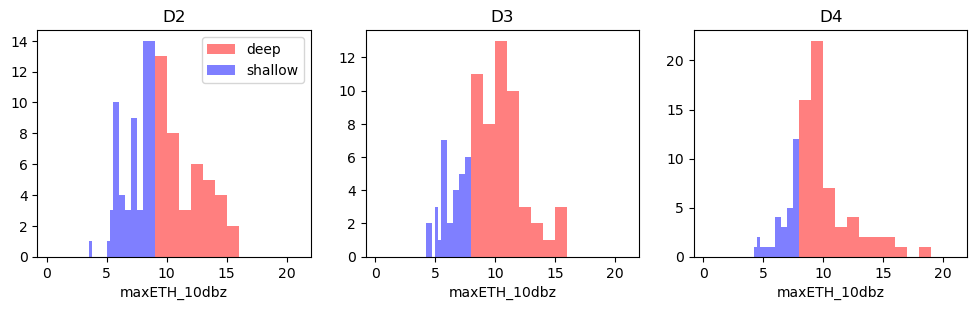

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(12,3), dpi=100)
# bins = np.arange(0, 18.1, 0.5)
bins = dsnms_d2.z.values/1000.
ax1 = axes[0]
ds_wide_deep_d2.maxETH_10dbz.isel(times=slice(tidx_start, tidx_end)).max(dim='times').plot.hist(bins=bins, color='r', alpha=0.5, ax=ax1, label='deep')
ds_wide_shallow_d2.maxETH_10dbz.isel(times=slice(tidx_start, tidx_end)).max(dim='times').plot.hist(bins=bins, color='b', alpha=0.5, ax=ax1, label='shallow')
ax1.legend()
ax1.set_title('D2')
ax2 = axes[1]
ds_wide_deep_d3.maxETH_10dbz.isel(times=slice(tidx_start, tidx_end)).max(dim='times').plot.hist(bins=bins, color='r', alpha=0.5, ax=ax2)
ds_wide_shallow_d3.maxETH_10dbz.isel(times=slice(tidx_start, tidx_end)).max(dim='times').plot.hist(bins=bins, color='b', alpha=0.5, ax=ax2)
ax2.set_title('D3')
ax3 = axes[2]
ds_wide_deep_d4.maxETH_10dbz.isel(times=slice(tidx_start, tidx_end)).max(dim='times').plot.hist(bins=bins, color='r', alpha=0.5, ax=ax3)
ds_wide_shallow_d4.maxETH_10dbz.isel(times=slice(tidx_start, tidx_end)).max(dim='times').plot.hist(bins=bins, color='b', alpha=0.5, ax=ax3)
ax3.set_title('D4')

Text(0.5, 1.0, 'D4')

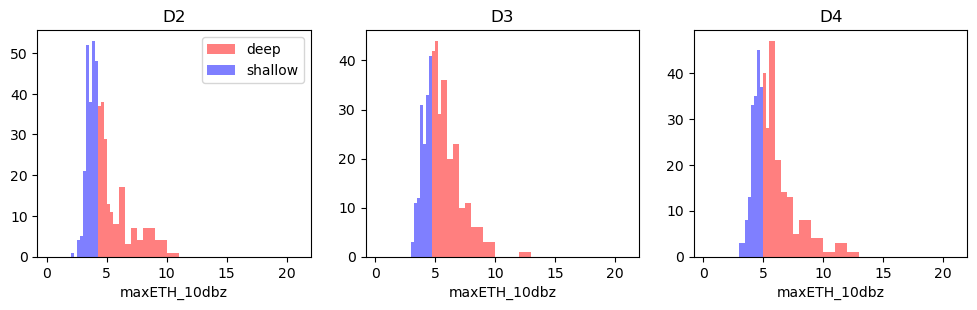

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(12,3), dpi=100)
bins = dsnms_d2.z.values/1000.
ax1 = axes[0]
ds_narrow_deep_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times').plot.hist(bins=bins, color='r', alpha=0.5, ax=ax1, label='deep')
ds_narrow_shallow_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times').plot.hist(bins=bins, color='b', alpha=0.5, ax=ax1, label='shallow')
ax1.legend()
ax1.set_title('D2')
ax2 = axes[1]
ds_narrow_deep_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times').plot.hist(bins=bins, color='r', alpha=0.5, ax=ax2)
ds_narrow_shallow_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times').plot.hist(bins=bins, color='b', alpha=0.5, ax=ax2)
ax2.set_title('D3')
ax3 = axes[2]
ds_narrow_deep_d4.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times').plot.hist(bins=bins, color='r', alpha=0.5, ax=ax3)
ds_narrow_shallow_d4.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times').plot.hist(bins=bins, color='b', alpha=0.5, ax=ax3)
ax3.set_title('D4')

## Group DataSets by dates

In [39]:
dates_narrow_d2 = ds_narrow_d2.date
dates_wide_d2 = ds_wide_d2.date

dates_narrow_d3 = ds_narrow_d3.date
dates_wide_d3 = ds_wide_d3.date

dates_narrow_d4 = ds_narrow_d4.date
dates_wide_d4 = ds_wide_d4.date

In [40]:
unique_dates = np.unique(dates_narrow_d2)
unique_dates_str = pd.to_datetime(unique_dates).strftime('%Y-%m-%d')
unique_dates_str

Index(['2018-11-29', '2018-12-04', '2018-12-05', '2019-01-22', '2019-01-23',
       '2019-01-25', '2019-01-29', '2019-02-08'],
      dtype='object')

In [41]:
ntracks_narrow_dates_d2 = ds_narrow_d2.tracks.groupby(dates_narrow_d2).count()
ntracks_wide_dates_d2 = ds_wide_d2.tracks.groupby(dates_wide_d2).count()

ntracks_narrow_dates_d3 = ds_narrow_d3.tracks.groupby(dates_narrow_d3).count()
ntracks_wide_dates_d3 = ds_wide_d3.tracks.groupby(dates_wide_d3).count()

ntracks_narrow_dates_d4 = ds_narrow_d4.tracks.groupby(dates_narrow_d4).count()
ntracks_wide_dates_d4 = ds_wide_d4.tracks.groupby(dates_wide_d4).count()

In [42]:
def plot_bars(bar_data, xlabel=None, ylabel=None, title=None, figsize=None, figname=None, fontsize=None, bold_xlabel=False, name_map=None):
    # plt.rcParams['font.family'] = 'DejaVu Serif'
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'

    x = np.arange(len(xlabel))  # the label locations
    width = 0.2  # the width of the bars
    lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    if name_map is None:
        name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}

    fig, ax = plt.subplots(figsize=figsize, dpi=100)
    bars2 = ax.bar(x - width, bar_data['d2'], width, label=name_map['d2'], color=lcolors['d2'])
    bars3 = ax.bar(x, bar_data['d3'], width, label=name_map['d3'], color=lcolors['d3'])
    bars4 = ax.bar(x + width, bar_data['d4'], width, label=name_map['d4'], color=lcolors['d4'])

    # Create font properties
    bold_font = FontProperties(weight='bold', family='Helvetica')
    regular_font = FontProperties(weight='normal', family='Helvetica')

    if bold_xlabel:
        # Function to format labels
        def format_label(label):
            parts = label.split('.')
            return f"$\\bf{{{parts[0]}}}$.{parts[1]}"

        # Format xlabels
        formatted_xlabels = [format_label(label) for label in xlabel]
    else:
        formatted_xlabels = xlabel

    # Add some text for labels, title and custom x-axis tick labels, etc.
    # ax.set_xlabel('Cases')
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left')
    ax.set_xticks(x)
    ax.set_xticklabels(formatted_xlabels, rotation=30, ha='right')
    ax.grid(ls=':', axis='y')
    ax.legend()

    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

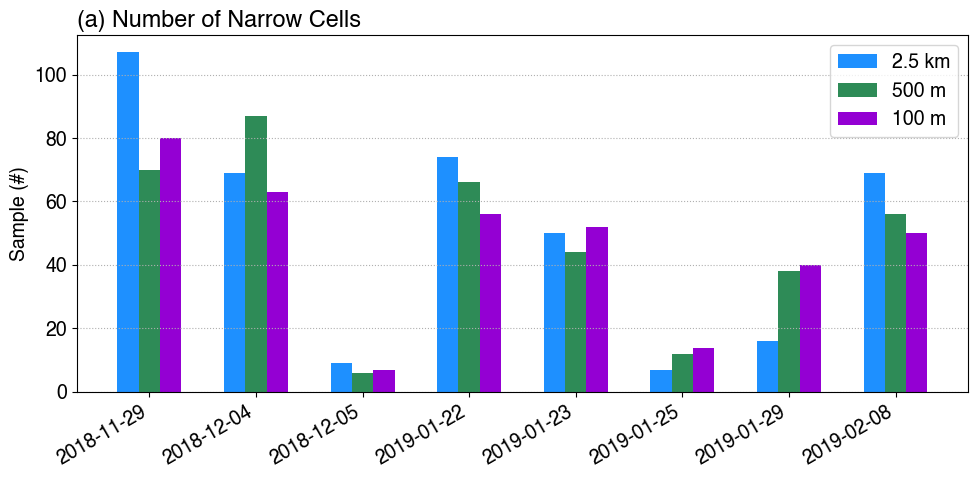

In [43]:
x = np.arange(len(unique_dates))
bar_data = {'d2':ntracks_narrow_dates_d2, 'd3':ntracks_narrow_dates_d3, 'd4':ntracks_narrow_dates_d4}
ylabel = 'Sample (#)'
title = '(a) Number of Narrow Cells'
fontsize = 14
figsize = [10,5]
figname = f'{figdir}CellNumberByDate_narrow_d2_d3_d4.png'
fig = plot_bars(bar_data, xlabel=unique_dates_str, ylabel=ylabel, title=title, fontsize=fontsize, figsize=figsize, figname=figname)

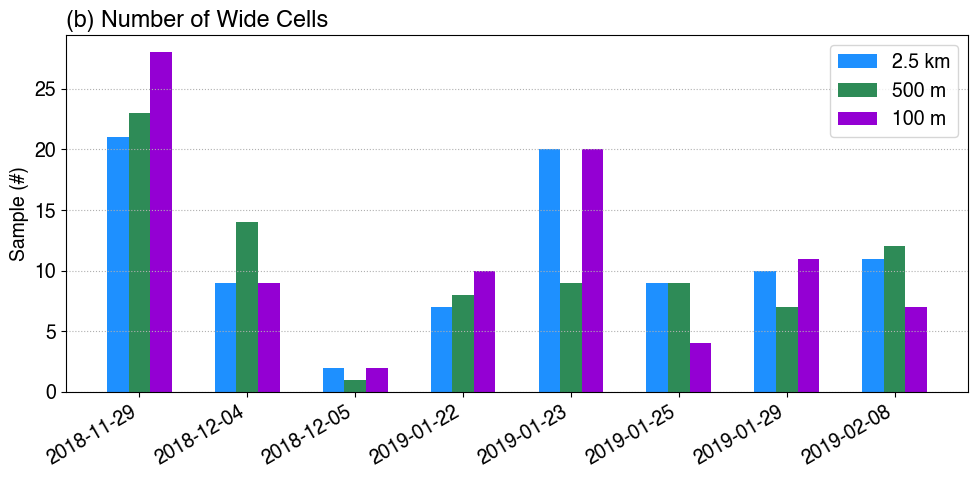

In [44]:
x = np.arange(len(unique_dates))
bar_data = {'d2':ntracks_wide_dates_d2, 'd3':ntracks_wide_dates_d3, 'd4':ntracks_wide_dates_d4}
ylabel = 'Sample (#)'
title = '(b) Number of Wide Cells'
fontsize = 14
figsize = [10,5]
figname = f'{figdir}CellNumberByDate_wide_d2_d3_d4.png'
fig = plot_bars(bar_data, xlabel=unique_dates_str, ylabel=ylabel, title=title, fontsize=fontsize, figsize=figsize, figname=figname)

In [45]:
# Median 10dBZ ETH by date
narrow_maxETH10dbz_thresh_bydate_d2 = ds_narrow_d2.CImaxETH_10dbz.groupby(dates_narrow_d2).median()
narrow_maxETH10dbz_thresh_bydate_d2

<xarray.DataArray 'CImaxETH_10dbz' (date: 8)> Size: 32B
array([4.   , 4.75 , 4.75 , 3.75 , 4.125, 5.   , 4.375, 3.5  ],
      dtype=float32)
Coordinates:
    core     int64 8B 0
  * date     (date) datetime64[ns] 64B 2018-11-29 2018-12-04 ... 2019-02-08

## Composite updraft profiles by aligning to cloud base, and group by ETH bins

In [46]:
def updraft_prof_cbase_nbins(ds, varname, operation=None, filter_Wmask=True, filter_muparcelht=True, quantiles=[0.25,0.5,0.75], nbins_ETH=None, return_ncell=False):
    
    # # Get dates
    # dates = ds.date
    # # Height coordinate for updraft variables
    # height_core = ds.z
    # Interpolated height coordinate [m]
    height_core_interp = np.arange(0, 20000.1, 200)

    # Get quantile-based bin edges for ETH
    # ETH_bins = np.quantile(ds["CImaxETH_10dbz"], np.linspace(0, 1, nbins_ETH + 1))
    # CImaxWTH = ds["Wtop"].max(dim='times')
    # ETH_bins = np.quantile(CImaxWTH, np.linspace(0, 1, nbins_ETH + 1))

    # Use Pandas qcut to produce equal-count bins
    # q=4 -> 4 equal-frequency bins; retbins=True returns the edges
    ETH_quantiles = np.linspace(0, 1, nbins_ETH + 1)
    # Convert DataArray to Pandas series
    s = pd.Series(ds["CImaxETH_10dbz"]).dropna()
    # Add a tiny reproducible jitter
    rng = np.random.RandomState(42)                # fixed seed for reproducibility
    eps = 1e-6 * (s.max() - s.min() + 1)          # tiny jitter scale relative to data range
    s_jitter = s + rng.uniform(-eps, eps, size=len(s))

    labels, ETH_bins = pd.qcut(s_jitter, q=ETH_quantiles, retbins=True)
    # top edges are ETH_bins[1:]
    ETH_bins_top = ETH_bins[1:]
    
    # Note: Wbase/Wtop unit is [km], convert to [m] to match original height coordinate
    # Average updraft base height
    Wbase_avg = ds['Wbase'].isel(times=slice(tidx_start, tidx_end)).mean(dim='times')*1000
    # Max updraft top height
    Wtop_max = ds['Wtop'].isel(times=slice(tidx_start, tidx_end)).max(dim='times')*1000
    # Cloud depth
    Wdepth = Wtop_max - Wbase_avg

    # Get variable from DataSet, mask with updraft mask, subset CI-period: filter heights below MU parcel height
    if filter_Wmask:
        VAR = ds[varname].where(ds["Wmask"] == True).isel(times=slice(tidx_start, tidx_end))
    else:
        VAR = ds[varname].isel(times=slice(tidx_start, tidx_end))

    VAR_mean_out = []
    VAR_inqt_out = []
    ns_prof_out = []
    Wdepth_mean_out = []
    Wdepth_inqt_out = []
    ntracks_out = []

    # Loop over each ETH bin
    for ii in range(nbins_ETH):
        # Make mask for the ETH bin
        mask = (ds["CImaxETH_10dbz"] >= ETH_bins[ii]) & (ds["CImaxETH_10dbz"] < ETH_bins[ii+1])

        # Use getattr to call the operation dynamically (e.g., operation: 'max', 'mean')
        VAR_s = getattr(VAR, operation)(dim=('times')).where(mask, drop=True)
        Wbase_s = Wbase_avg.where(mask, drop=True)
        Wdepth_s = Wdepth.where(mask, drop=True)
        # Save number of cells after filter
        ntracks_out.append(VAR_s.sizes['tracks'])
        # print(VAR_s.sizes['tracks'])
        
        # Interpolate VAR to constant-spaced height
        VAR_s_interp = VAR_s.interp(z=height_core_interp)

        # Broadcast Wbase to match the VAR shape
        _Wbase_s = Wbase_s.broadcast_like(VAR_s_interp)
        
        # Shift the height coordinate by Wbase height, the new coordinate 'z' will be 2D [z,tracks]
        VAR_s_shifted = VAR_s_interp.assign_coords({'z':(VAR_s_interp.coords['z'] - _Wbase_s)})
        # VAR_d_shifted = VAR_d_interp.assign_coords({'z':(VAR_d_interp.coords['z'] - _Wbase_d)})
        VAR_s_shifted['z'].attrs = {'units':'m'}
        
        VAR_s_Wbase = []
        # Loop over each track
        for track_idx in range(len(VAR_s_shifted.coords['tracks'])):
            # Select one track at a time
            _VAR = VAR_s_shifted.isel(tracks=track_idx)
            # Interpolate again to the new common height grid
            _VAR_interp = _VAR.interp(z=height_core_interp)
            # Store the aligned profile
            VAR_s_Wbase.append(_VAR_interp)
            
        # Stack the aligned profiles along a new dimension
        VAR_s_Wbase = xr.concat(VAR_s_Wbase, dim='tracks')
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            # Compute mean
            VAR_s_mean = VAR_s_Wbase.mean(dim='tracks', keep_attrs=True)
            # Compute quantiles
            VAR_s_inqt = VAR_s_Wbase.quantile(quantiles, dim='tracks', keep_attrs=True)
            # Get sample size profiles by dates
            ns_prof_s = (~np.isnan(VAR_s_Wbase)).sum(dim='tracks')
            # Depth statistics
            Wdepth_s_mean = Wdepth_s.mean(keep_attrs=True)
            Wdepth_s_inqt = Wdepth_s.quantile(quantiles)

        # Append the profiles for output
        VAR_mean_out.append(VAR_s_mean)
        VAR_inqt_out.append(VAR_s_inqt)
        ns_prof_out.append(ns_prof_s)
        Wdepth_mean_out.append(Wdepth_s_mean)
        Wdepth_inqt_out.append(Wdepth_s_inqt)

    # Convert list to DataArray by a new dimension
    VAR_mean_out = xr.concat(VAR_mean_out, dim='ETH')
    VAR_inqt_out = xr.concat(VAR_inqt_out, dim='ETH')
    ns_prof_out = xr.concat(ns_prof_out, dim='ETH')
    Wdepth_mean_out = xr.concat(Wdepth_mean_out, dim='ETH')
    Wdepth_inqt_out = xr.concat(Wdepth_inqt_out, dim='ETH')
    # Assign coordinate
    VAR_mean_out = VAR_mean_out.assign_coords({'ETH':ETH_bins_top})
    VAR_inqt_out = VAR_inqt_out.assign_coords({'ETH':ETH_bins_top})
    ns_prof_out = ns_prof_out.assign_coords({'ETH':ETH_bins_top})
    Wdepth_mean_out = Wdepth_mean_out.assign_coords({'ETH':ETH_bins_top})
    Wdepth_inqt_out = Wdepth_inqt_out.assign_coords({'ETH':ETH_bins_top})
    
    if return_ncell:
        return VAR_mean_out, VAR_inqt_out, ns_prof_out, Wdepth_mean_out, Wdepth_inqt_out, ETH_bins, ntracks_out
    else:
        return VAR_mean_out, VAR_inqt_out, ns_prof_out, Wdepth_mean_out, Wdepth_inqt_out, ETH_bins

In [47]:
quantiles = [0.25, 0.5, 0.75]
# quantiles = [0.5]
nbins_ETH = 4
# Buoyancy
MaxCoreBuoy_n_avg_d2, MaxCoreBuoy_n_inqt_d2, nsMaxCoreBuoy_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'CoreBuoyThtv_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreBuoy_w_avg_d2, MaxCoreBuoy_w_inqt_d2, nsMaxCoreBuoy_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2, 'CoreBuoyThtv_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [48]:
# Buoyancy
MaxCoreBuoy_n_avg_d3, MaxCoreBuoy_n_inqt_d3, nsMaxCoreBuoy_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'CoreBuoyThtv_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreBuoy_w_avg_d3, MaxCoreBuoy_w_inqt_d3, nsMaxCoreBuoy_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3, 'CoreBuoyThtv_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [49]:
# Buoyancy
MaxCoreBuoy_n_avg_d4, MaxCoreBuoy_n_inqt_d4, nsMaxCoreBuoy_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'CoreBuoyThtv_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreBuoy_w_avg_d4, MaxCoreBuoy_w_inqt_d4, nsMaxCoreBuoy_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4, 'CoreBuoyThtv_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [50]:
# Buoyancy (based on density potential temperature)
MaxCoreBuoyTrho_n_avg_d2, MaxCoreBuoyTrho_n_inqt_d2, nsMaxCoreBuoyTrho_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'CoreBuoyTrho_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreBuoyTrho_w_avg_d2, MaxCoreBuoyTrho_w_inqt_d2, nsMaxCoreBuoyTrho_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2, 'CoreBuoyTrho_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [51]:
# Buoyancy (based on density potential temperature)
MaxCoreBuoyTrho_n_avg_d3, MaxCoreBuoyTrho_n_inqt_d3, nsMaxCoreBuoyTrho_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'CoreBuoyTrho_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreBuoyTrho_w_avg_d3, MaxCoreBuoyTrho_w_inqt_d3, nsMaxCoreBuoyTrho_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3, 'CoreBuoyTrho_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [52]:
# Buoyancy (based on density potential temperature)
MaxCoreBuoyTrho_n_avg_d4, MaxCoreBuoyTrho_n_inqt_d4, nsMaxCoreBuoyTrho_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'CoreBuoyTrho_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreBuoyTrho_w_avg_d4, MaxCoreBuoyTrho_w_inqt_d4, nsMaxCoreBuoyTrho_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4, 'CoreBuoyTrho_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [53]:
# Core diameter
MaxCoreArea_n_avg_d2, MaxCoreArea_n_inqt_d2, nsMaxCoreDiam_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2, nCells_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'CoreArea_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH, return_ncell=True)
MaxCoreArea_w_avg_d2, MaxCoreArea_w_inqt_d2, nsMaxCoreDiam_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2, nCells_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2, 'CoreArea_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH, return_ncell=True)

# Convert area to equivalent diameter
MaxCoreDiam_n_avg_d2 = 2*np.sqrt(MaxCoreArea_n_avg_d2/np.pi)
MaxCoreDiam_n_inqt_d2 = 2*np.sqrt(MaxCoreArea_n_inqt_d2/np.pi)
MaxCoreDiam_w_avg_d2 = 2*np.sqrt(MaxCoreArea_w_avg_d2/np.pi)
MaxCoreDiam_w_inqt_d2 = 2*np.sqrt(MaxCoreArea_w_inqt_d2/np.pi)


In [54]:
# Core diameter
MaxCoreArea_n_avg_d3, MaxCoreArea_n_inqt_d3, nsMaxCoreDiam_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3, nCells_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'CoreArea_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH, return_ncell=True)
MaxCoreArea_w_avg_d3, MaxCoreArea_w_inqt_d3, nsMaxCoreDiam_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3, nCells_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3, 'CoreArea_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH, return_ncell=True)

# Convert area to equivalent diameter
MaxCoreDiam_n_avg_d3 = 2*np.sqrt(MaxCoreArea_n_avg_d3/np.pi)
MaxCoreDiam_n_inqt_d3 = 2*np.sqrt(MaxCoreArea_n_inqt_d3/np.pi)
MaxCoreDiam_w_avg_d3 = 2*np.sqrt(MaxCoreArea_w_avg_d3/np.pi)
MaxCoreDiam_w_inqt_d3 = 2*np.sqrt(MaxCoreArea_w_inqt_d3/np.pi)

In [55]:
# Core diameter
MaxCoreArea_n_avg_d4, MaxCoreArea_n_inqt_d4, nsMaxCoreDiam_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4, nCells_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'CoreArea_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH, return_ncell=True)
MaxCoreArea_w_avg_d4, MaxCoreArea_w_inqt_d4, nsMaxCoreDiam_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4, nCells_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4, 'CoreArea_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH, return_ncell=True)

# Convert area to equivalent diameter
MaxCoreDiam_n_avg_d4 = 2*np.sqrt(MaxCoreArea_n_avg_d4/np.pi)
MaxCoreDiam_n_inqt_d4 = 2*np.sqrt(MaxCoreArea_n_inqt_d4/np.pi)
MaxCoreDiam_w_avg_d4 = 2*np.sqrt(MaxCoreArea_w_avg_d4/np.pi)
MaxCoreDiam_w_inqt_d4 = 2*np.sqrt(MaxCoreArea_w_inqt_d4/np.pi)

In [56]:
# Number of cores
NCore_n_avg_d2, NCore_n_inqt_d2, nsNCore_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'nCore_up', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)
NCore_w_avg_d2, NCore_w_inqt_d2, nsNCore_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2, 'nCore_up', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [57]:
# Number of cores
NCore_n_avg_d3, NCore_n_inqt_d3, nsNCore_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'nCore_up', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)
NCore_w_avg_d3, NCore_w_inqt_d3, nsNCore_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3, 'nCore_up', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [58]:
# Number of cores
NCore_n_avg_d4, NCore_n_inqt_d4, nsNCore_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'nCore_up', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)
NCore_w_avg_d4, NCore_w_inqt_d4, nsNCore_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4, 'nCore_up', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)

### Excluding 2018 cases for testing wide cells

In [59]:
# Exclude 2018 dates for testing wide cells
min_date = pd.Timestamp('2019-01-01')
ds_wide_d4_2019 = ds_wide_d4.where(ds_wide_d4.date > min_date, drop=True)

MaxCoreArea_w_avg_d4_2019, MaxCoreArea_w_inqt_d4_2019, nsMaxCoreDiam_w_d4_2019, Wdepth_w_avg_d4_2019, Wdepth_w_inqt_d4_2019, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4_2019, 'CoreArea_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

# Convert area to equivalent diameter
MaxCoreDiam_w_avg_d4_2019 = 2*np.sqrt(MaxCoreArea_w_avg_d4_2019/np.pi)
MaxCoreDiam_w_inqt_d4_2019 = 2*np.sqrt(MaxCoreArea_w_inqt_d4_2019/np.pi)

In [60]:
# Core Mass Flux
MaxCoreMassFlux_n_avg_d2, MaxCoreMassFlux_n_inqt_d2, nsMaxCoreMassFlux_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'CoreMassFlux_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreMassFlux_w_avg_d2, MaxCoreMassFlux_w_inqt_d2, nsMaxCoreMassFlux_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2, 'CoreMassFlux_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [61]:
# Core Mass Flux
MaxCoreMassFlux_n_avg_d3, MaxCoreMassFlux_n_inqt_d3, nsMaxCoreMassFlux_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'CoreMassFlux_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreMassFlux_w_avg_d3, MaxCoreMassFlux_w_inqt_d3, nsMaxCoreMassFlux_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3, 'CoreMassFlux_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [62]:
# Core Mass Flux
MaxCoreMassFlux_n_avg_d4, MaxCoreMassFlux_n_inqt_d4, nsMaxCoreMassFlux_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'CoreMassFlux_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreMassFlux_w_avg_d4, MaxCoreMassFlux_w_inqt_d4, nsMaxCoreMassFlux_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4, 'CoreMassFlux_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)


In [63]:
# Core Mean W
MaxCoreMeanW_n_avg_d2, MaxCoreMeanW_n_inqt_d2, nsMaxCoreMeanW_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'CoreMeanW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreMeanW_w_avg_d2, MaxCoreMeanW_w_inqt_d2, nsMaxCoreMeanW_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2,'CoreMeanW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [64]:
# Core Mean W
MaxCoreMeanW_n_avg_d3, MaxCoreMeanW_n_inqt_d3, nsMaxCoreMeanW_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'CoreMeanW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreMeanW_w_avg_d3, MaxCoreMeanW_w_inqt_d3, nsMaxCoreMeanW_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3,'CoreMeanW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [65]:
# Core Mean W
MaxCoreMeanW_n_avg_d4, MaxCoreMeanW_n_inqt_d4, nsMaxCoreMeanW_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'CoreMeanW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreMeanW_w_avg_d4, MaxCoreMeanW_w_inqt_d4, nsMaxCoreMeanW_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4,'CoreMeanW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [66]:
# Core Max W
MaxCoreMaxW_n_avg_d2, MaxCoreMaxW_n_inqt_d2, nsMaxCoreMaxW_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'CoreMaxW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreMaxW_w_avg_d2, MaxCoreMaxW_w_inqt_d2, nsMaxCoreMaxW_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2,'CoreMaxW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [67]:
# Core Max W
MaxCoreMaxW_n_avg_d3, MaxCoreMaxW_n_inqt_d3, nsMaxCoreMaxW_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'CoreMaxW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreMaxW_w_avg_d3, MaxCoreMaxW_w_inqt_d3, nsMaxCoreMaxW_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3,'CoreMaxW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [68]:
# Core Max W
MaxCoreMaxW_n_avg_d4, MaxCoreMaxW_n_inqt_d4, nsMaxCoreMaxW_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'CoreMaxW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreMaxW_w_avg_d4, MaxCoreMaxW_w_inqt_d4, nsMaxCoreMaxW_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4,'CoreMaxW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [69]:
# Core Perimeter RH
MeanShellRH_n_avg_d2, MeanShellRH_n_inqt_d2, nsMeanShellRH_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'CoreRhMean_prm', operation='mean', quantiles=quantiles, nbins_ETH=nbins_ETH)
MeanShellRH_w_avg_d2, MeanShellRH_w_inqt_d2, nsMeanShellRH_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2, 'CoreRhMean_prm', operation='mean', quantiles=quantiles, nbins_ETH=nbins_ETH)

MedianShellRH_n_avg_d2, MedianShellRH_n_inqt_d2, nsMedianShellRH_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'CoreRhMean_prm', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)
MedianShellRH_w_avg_d2, MedianShellRH_w_inqt_d2, nsMedianShellRH_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2, 'CoreRhMean_prm', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [70]:
# Core Perimeter RH
MeanShellRH_n_avg_d3, MeanShellRH_n_inqt_d3, nsMeanShellRH_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'CoreRhMean_prm', operation='mean', quantiles=quantiles, nbins_ETH=nbins_ETH)
MeanShellRH_w_avg_d3, MeanShellRH_w_inqt_d3, nsMeanShellRH_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3, 'CoreRhMean_prm', operation='mean', quantiles=quantiles, nbins_ETH=nbins_ETH)

MedianShellRH_n_avg_d3, MedianShellRH_n_inqt_d3, nsMedianShellRH_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'CoreRhMean_prm', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)
MedianShellRH_w_avg_d3, MedianShellRH_w_inqt_d3, nsMedianShellRH_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3, 'CoreRhMean_prm', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [71]:
# Core Perimeter RH
MeanShellRH_n_avg_d4, MeanShellRH_n_inqt_d4, nsMeanShellRH_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'CoreRhMean_prm', operation='mean', quantiles=quantiles, nbins_ETH=nbins_ETH)
MeanShellRH_w_avg_d4, MeanShellRH_w_inqt_d4, nsMeanShellRH_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4, 'CoreRhMean_prm', operation='mean', quantiles=quantiles, nbins_ETH=nbins_ETH)

MedianShellRH_n_avg_d4, MedianShellRH_n_inqt_d4, nsMedianShellRH_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'CoreRhMean_prm', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)
MedianShellRH_w_avg_d4, MedianShellRH_w_inqt_d4, nsMedianShellRH_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4, 'CoreRhMean_prm', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)

## Plot composite profiles bin my cell depth

In [72]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

def plot_mxn_prof(nrow, ncol, prof, height, shade_cbase=False,
                  xlabels=None, ylabels=None, xlims=None, ylims=None, z_thresh=None, 
                  legend_text=None, legend_ns=None, legend_show=None, legend_loc=None, legend_title=None,
                  cmap='jet', cmap_range=(0.1,0.9), titles=None, fontsize=None, figsize=None, figname=None,):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'

    # Choose a sequential colormap (e.g., "viridis", "plasma", "Blues", etc.)
    cmap = plt.get_cmap(cmap)
    cmap = truncate_colormap(cmap, cmap_range[0], cmap_range[1])
    n_prof = prof[0][0].shape[0]  # Number of profiles
    # Get N equally spaced values between 0 and 1
    color_positions = np.linspace(0, 1, n_prof)
    # Sample the colormap at those positions
    lcolors = [cmap(pos) for pos in color_positions]
    # lcolors = ['deepskyblue', 'forestgreen', 'gold', 'orangered', 'maroon']
    
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=100)
    lstyles = {'min':'-', 'max':'-'}
    lw = 3
    alpha = 0.3
    
    for row in range(nrow):
        for col in range(ncol):
            ax = axes[row][col]
            prof_data = prof[row][col]
            # inqt_data = inqt[row][col]
            legend_tx = legend_text[row][col]
            if legend_ns is not None: 
                legend_ns_tx = legend_ns[row][col]
            for pp in range(n_prof):
                if legend_ns is not None:
                    legend_label = f"{legend_tx[pp]:.1f} km ({legend_ns_tx[pp]})"
                else:
                    legend_label = f"{legend_tx[pp]:.1f} km"
                ax.plot(prof_data.values[pp], height, color=lcolors[pp], label=legend_label, lw=lw, ls=lstyles['min'])
                # ax.fill_betweenx(height, inqt_data['s'][0], inqt_data['s'][1], facecolor=lcolors['s'], alpha=alpha)
                # ax.fill_betweenx(height, inqt_data['d'][0], inqt_data['d'][1], facecolor=lcolors['d'], alpha=alpha)
            if (legend_show is not None):
                if (legend_show[row][col]): ax.legend(loc=legend_loc, title=legend_title)
            if (z_thresh is not None): 
                _z_thresh = z_thresh[row][col]
                ax.axhline(_z_thresh, linestyle='--', lw=2, color='k')
            if (xlims is not None): ax.set_xlim(min(xlims[row][col]), max(xlims[row][col]))
            if (ylims is not None): ax.set_ylim(min(ylims), max(ylims))
            ax.set_xlabel(xlabels[row][col])
            ax.set_ylabel(ylabels[row][col])
            ax.set_title(titles[row][col], loc='left')
            ax.grid(ls=':')
            # Shade cloud-base region
            if shade_cbase:
                ax.axhspan(0, 0.5, facecolor='lightgray', alpha=0.7)
            
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/CIMax_CbaseProfile_NarrowWide_byETH_NsampleCoreMaxDiameter_d2_d3_d4.png


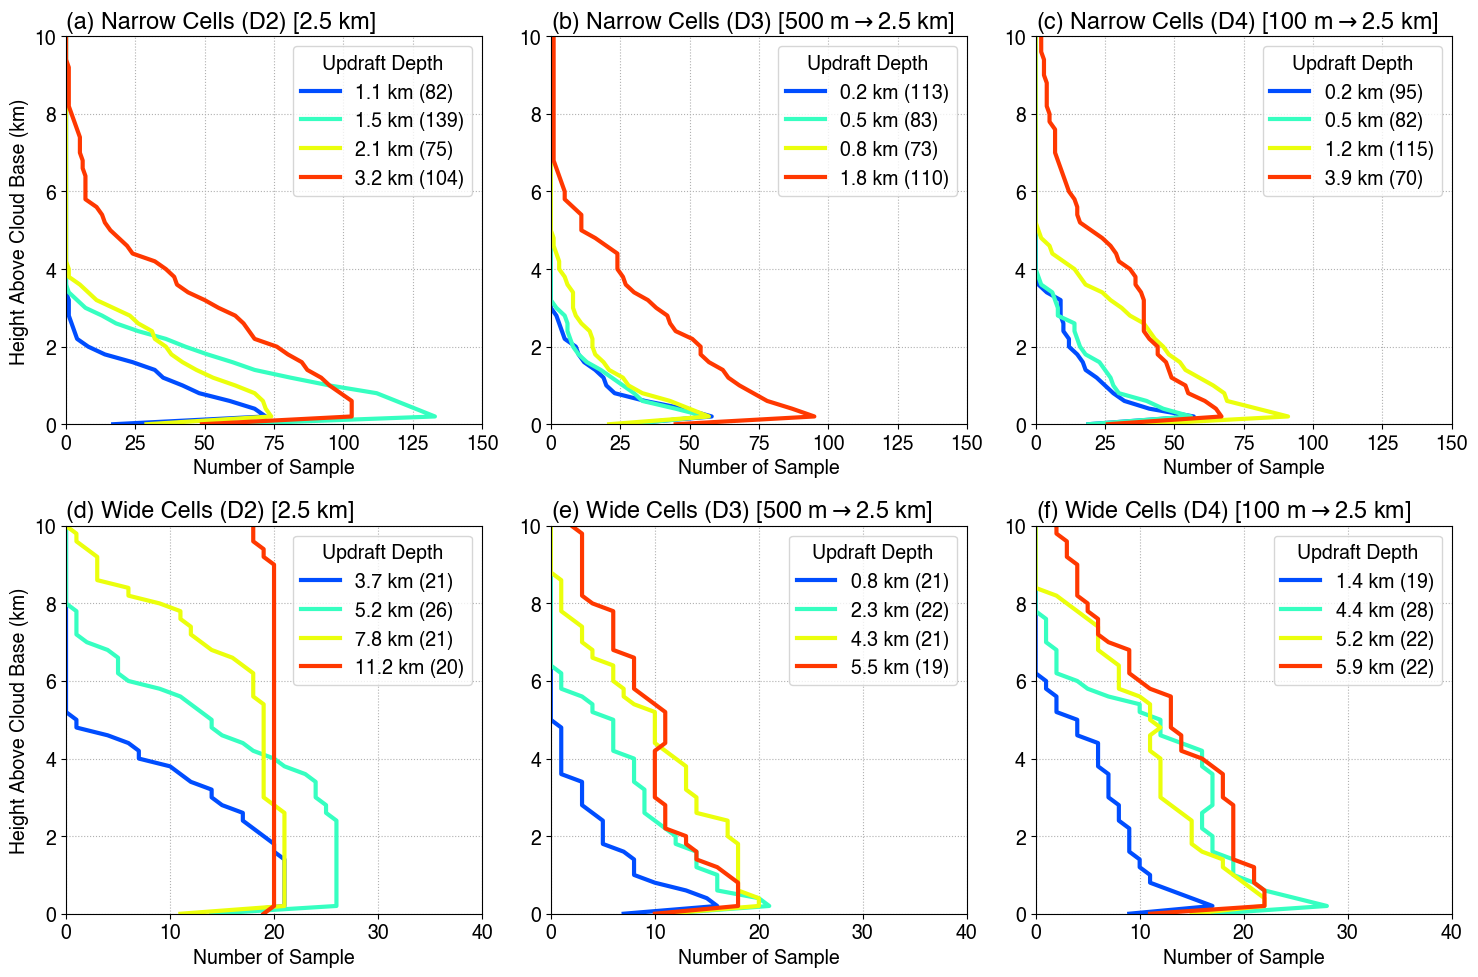

In [73]:
THRESH_w = 0
THRESH_n = 0
height_wbase = MaxCoreBuoyTrho_n_avg_d2.z / 1000.
# Number of samples profiles for core buoyancy Trho
med_n_d2 = nsMaxCoreDiam_n_d2
med_n_d3 = nsMaxCoreDiam_n_d3
med_n_d4 = nsMaxCoreDiam_n_d4

med_w_d2 = nsMaxCoreDiam_w_d2
med_w_d3 = nsMaxCoreDiam_w_d3
med_w_d4 = nsMaxCoreDiam_w_d4

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Number of Sample']*ncol,
    ['Number of Sample']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', r'(b) Narrow Cells (D3) [500 m$\rightarrow$2.5 km]', r'(c) Narrow Cells (D4) [100 m$\rightarrow$2.5 km]'],
    ['(d) Wide Cells (D2) [2.5 km]', r'(e) Wide Cells (D3) [500 m$\rightarrow$2.5 km]', r'(f) Wide Cells (D4) [100 m$\rightarrow$2.5 km]'],
]
ylims = (0,10)
xlims = [
    [(0,150)]*ncol,
    [(0,40)]*ncol,
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'best'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_NsampleCoreMaxDiameter_d2_d3_d4.png'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, shade_cbase=False,
                     z_thresh=z_thresh, legend_show=legend_show, legend_loc=legend_loc, legend_text=legend_text, legend_ns=legend_ns, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/CIMax_CbaseProfile_NarrowWide_byETH_NCores_d2_d3_d4.png


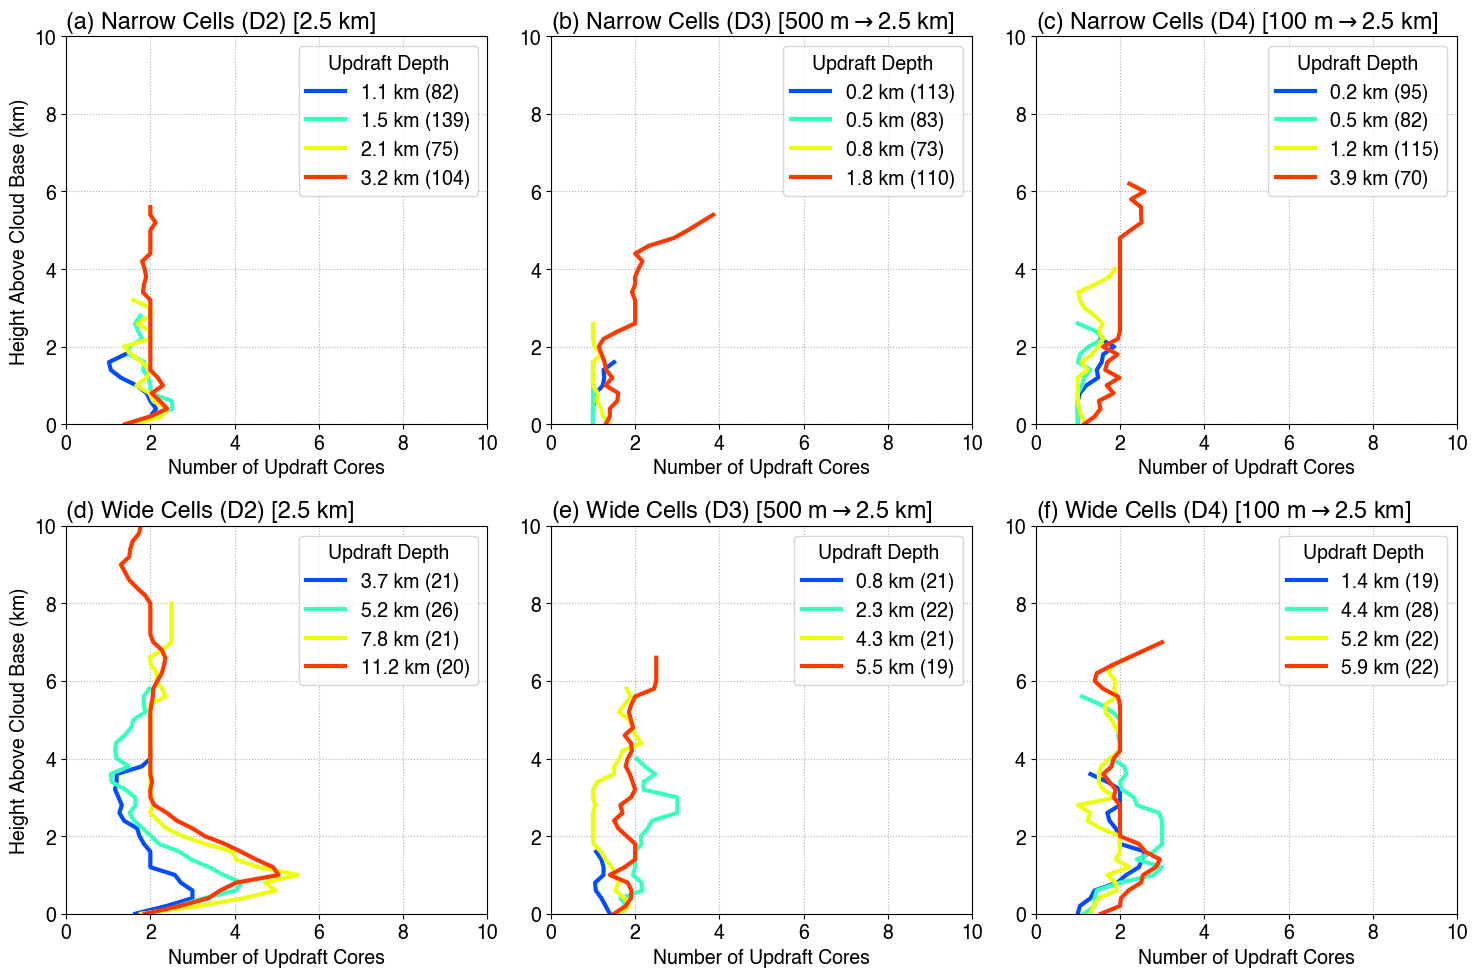

In [74]:
THRESH_w = 6
THRESH_n = 10
height_wbase = NCore_n_avg_d2.z / 1000.
# Median profiles
med_w_d2 = NCore_w_inqt_d2.sel(quantile=0.5).where(nsNCore_w_d2 > THRESH_w)
med_w_d3 = NCore_w_inqt_d3.sel(quantile=0.5).where(nsNCore_w_d3 > THRESH_w)
med_w_d4 = NCore_w_inqt_d4.sel(quantile=0.5).where(nsNCore_w_d4 > THRESH_w)

med_n_d2 = NCore_n_inqt_d2.sel(quantile=0.5).where(nsNCore_n_d2 > THRESH_n)
med_n_d3 = NCore_n_inqt_d3.sel(quantile=0.5).where(nsNCore_n_d3 > THRESH_n)
med_n_d4 = NCore_n_inqt_d4.sel(quantile=0.5).where(nsNCore_n_d4 > THRESH_n)

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Number of Updraft Cores']*ncol,
    ['Number of Updraft Cores']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', r'(b) Narrow Cells (D3) [500 m$\rightarrow$2.5 km]', r'(c) Narrow Cells (D4) [100 m$\rightarrow$2.5 km]'],
    ['(d) Wide Cells (D2) [2.5 km]', r'(e) Wide Cells (D3) [500 m$\rightarrow$2.5 km]', r'(f) Wide Cells (D4) [100 m$\rightarrow$2.5 km]'],
]
ylims = (0,10)
xlims = [
    [(0,10)]*ncol,
    [(0,10)]*ncol,
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'best'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_NCores_d2_d3_d4.png'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, shade_cbase=False,
                     z_thresh=z_thresh, legend_show=legend_show, legend_ns=legend_ns, legend_loc=legend_loc, legend_text=legend_text, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/CIMax_CbaseProfile_NarrowWide_byETH_CoreMaxBuoyancy_d2_d3_d4.png


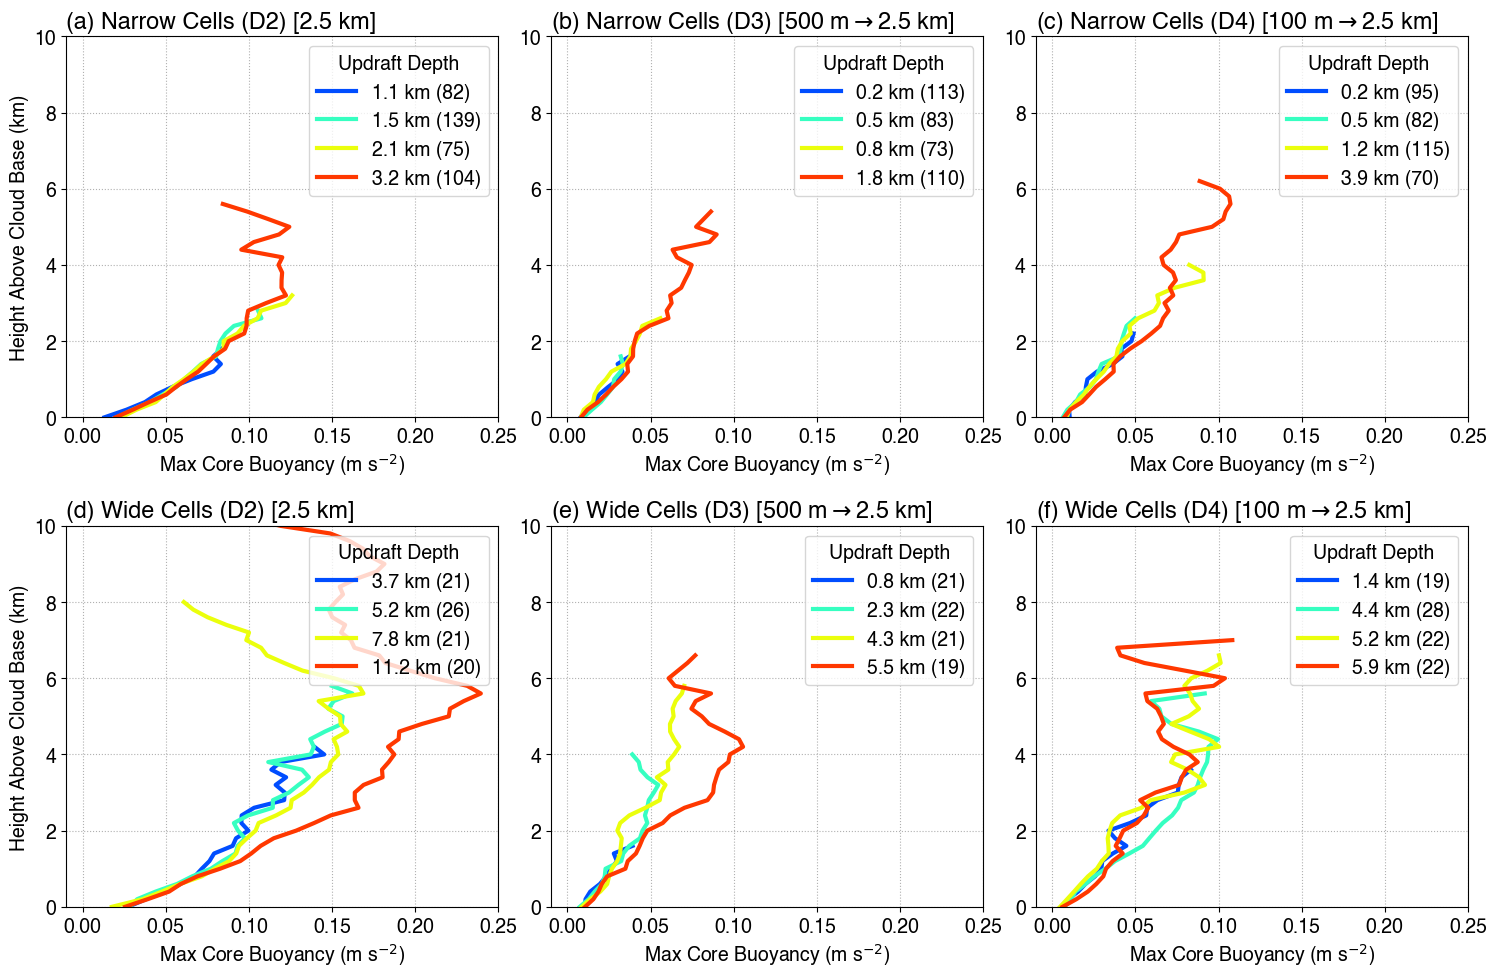

In [75]:
# THRESH_w = 10
# THRESH_n = 20
THRESH_w = 6
THRESH_n = 10
height_wbase = MaxCoreBuoy_n_avg_d2.z / 1000.
# Median profiles
med_w_d2 = MaxCoreBuoy_w_inqt_d2.sel(quantile=0.5).where(nsMaxCoreBuoy_w_d2 > THRESH_w)
med_w_d3 = MaxCoreBuoy_w_inqt_d3.sel(quantile=0.5).where(nsMaxCoreBuoy_w_d3 > THRESH_w)
med_w_d4 = MaxCoreBuoy_w_inqt_d4.sel(quantile=0.5).where(nsMaxCoreBuoy_w_d4 > THRESH_w)

med_n_d2 = MaxCoreBuoy_n_inqt_d2.sel(quantile=0.5).where(nsMaxCoreBuoy_n_d2 > THRESH_n)
med_n_d3 = MaxCoreBuoy_n_inqt_d3.sel(quantile=0.5).where(nsMaxCoreBuoy_n_d3 > THRESH_n)
med_n_d4 = MaxCoreBuoy_n_inqt_d4.sel(quantile=0.5).where(nsMaxCoreBuoy_n_d4 > THRESH_n)

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

# legend_text = [
#     [med_n_d2.ETH.values, med_n_d3.ETH.values, med_n_d4.ETH.values],
#     [med_w_d2.ETH.values, med_w_d3.ETH.values, med_w_d4.ETH.values],
# ]
Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Max Core Buoyancy (m s$^{-2}$)']*ncol,
    ['Max Core Buoyancy (m s$^{-2}$)']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', r'(b) Narrow Cells (D3) [500 m$\rightarrow$2.5 km]', r'(c) Narrow Cells (D4) [100 m$\rightarrow$2.5 km]'],
    ['(d) Wide Cells (D2) [2.5 km]', r'(e) Wide Cells (D3) [500 m$\rightarrow$2.5 km]', r'(f) Wide Cells (D4) [100 m$\rightarrow$2.5 km]'],
]
ylims = (0,10)
xlims = [
    [(-0.01,0.25)]*ncol,
    [(-0.01,0.25)]*ncol,
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'upper right'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_CoreMaxBuoyancy_d2_d3_d4.png'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, shade_cbase=False,
                     z_thresh=z_thresh, legend_show=legend_show, legend_ns=legend_ns, legend_loc=legend_loc, legend_text=legend_text, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/CIMax_CbaseProfile_NarrowWide_byETH_CoreMaxBuoyancyTrho_d2_d3_d4.png


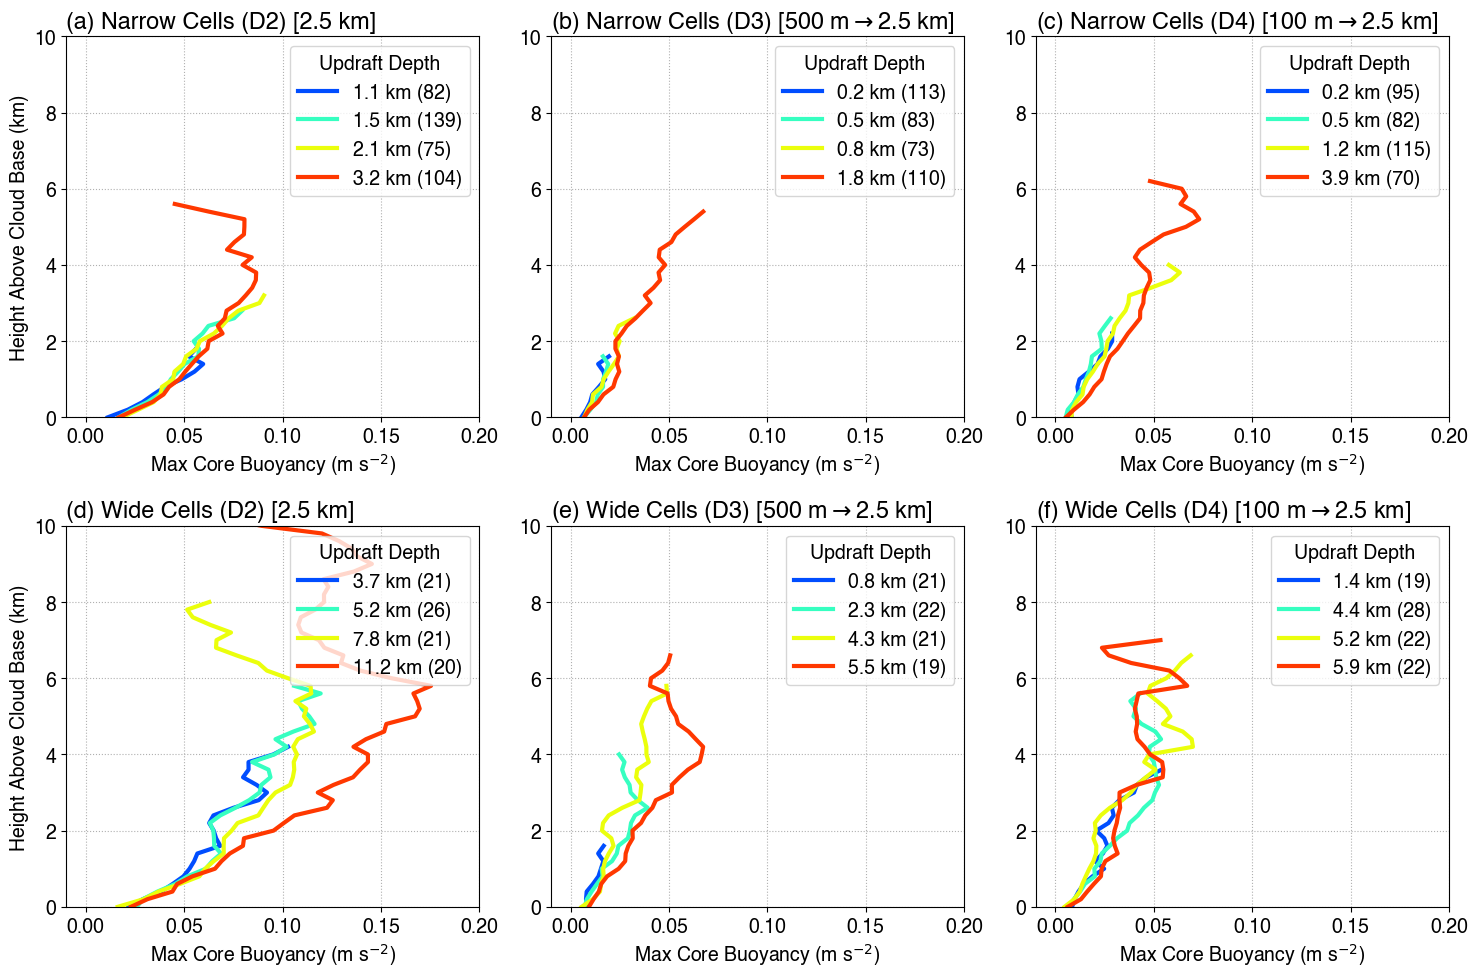

In [76]:
THRESH_w = 6
THRESH_n = 10
height_wbase = MaxCoreBuoyTrho_n_avg_d2.z / 1000.
# Median profiles
med_w_d2 = MaxCoreBuoyTrho_w_inqt_d2.sel(quantile=0.5).where(nsMaxCoreBuoyTrho_w_d2 > THRESH_w)
med_w_d3 = MaxCoreBuoyTrho_w_inqt_d3.sel(quantile=0.5).where(nsMaxCoreBuoyTrho_w_d3 > THRESH_w)
med_w_d4 = MaxCoreBuoyTrho_w_inqt_d4.sel(quantile=0.5).where(nsMaxCoreBuoyTrho_w_d4 > THRESH_w)

med_n_d2 = MaxCoreBuoyTrho_n_inqt_d2.sel(quantile=0.5).where(nsMaxCoreBuoyTrho_n_d2 > THRESH_n)
med_n_d3 = MaxCoreBuoyTrho_n_inqt_d3.sel(quantile=0.5).where(nsMaxCoreBuoyTrho_n_d3 > THRESH_n)
med_n_d4 = MaxCoreBuoyTrho_n_inqt_d4.sel(quantile=0.5).where(nsMaxCoreBuoyTrho_n_d4 > THRESH_n)

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Max Core Buoyancy (m s$^{-2}$)']*ncol,
    ['Max Core Buoyancy (m s$^{-2}$)']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', r'(b) Narrow Cells (D3) [500 m$\rightarrow$2.5 km]', r'(c) Narrow Cells (D4) [100 m$\rightarrow$2.5 km]'],
    ['(d) Wide Cells (D2) [2.5 km]', r'(e) Wide Cells (D3) [500 m$\rightarrow$2.5 km]', r'(f) Wide Cells (D4) [100 m$\rightarrow$2.5 km]'],
]
ylims = (0,10)
xlims = [
    [(-0.01,0.2)]*ncol,
    [(-0.01,0.2)]*ncol,
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'upper right'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_CoreMaxBuoyancyTrho_d2_d3_d4.png'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, shade_cbase=False,
                     z_thresh=z_thresh, legend_show=legend_show, legend_loc=legend_loc, legend_text=legend_text, legend_ns=legend_ns, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/CIMax_CbaseProfile_NarrowWide_byETH_CoreMaxDiameter_d2_d3_d4.png


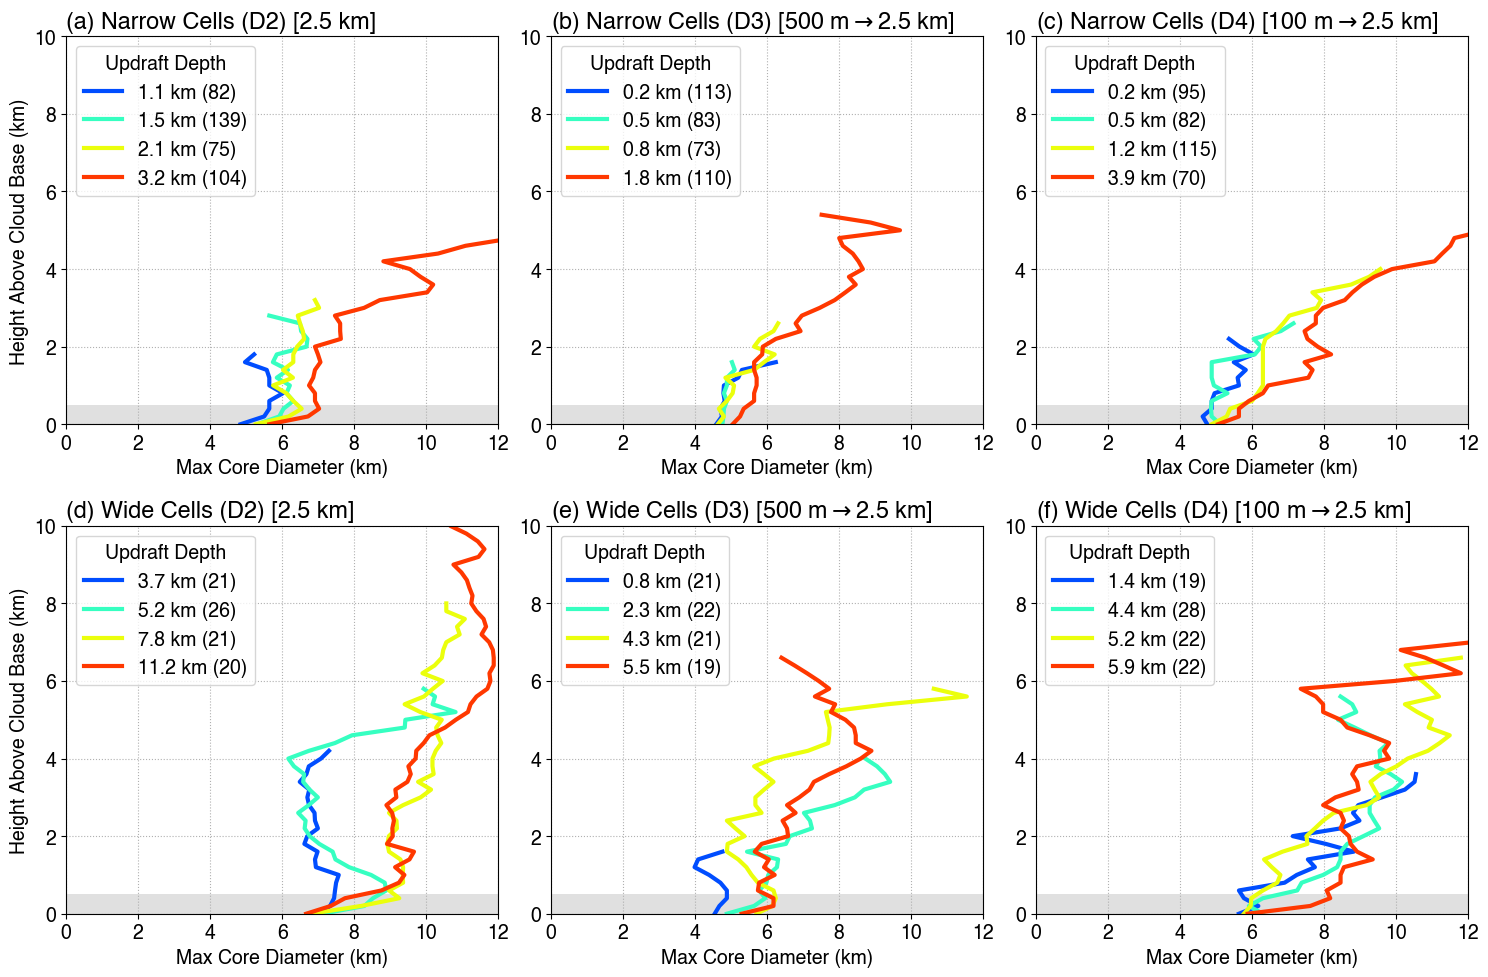

In [82]:
THRESH_w = 6
THRESH_n = 10
height_wbase = MaxCoreDiam_n_avg_d2.z / 1000.
# Median profiles
med_w_d2 = MaxCoreDiam_w_inqt_d2.sel(quantile=0.5).where(nsMaxCoreDiam_w_d2 > THRESH_w)
med_w_d3 = MaxCoreDiam_w_inqt_d3.sel(quantile=0.5).where(nsMaxCoreDiam_w_d3 > THRESH_w)
med_w_d4 = MaxCoreDiam_w_inqt_d4.sel(quantile=0.5).where(nsMaxCoreDiam_w_d4 > THRESH_w)

med_n_d2 = MaxCoreDiam_n_inqt_d2.sel(quantile=0.5).where(nsMaxCoreDiam_n_d2 > THRESH_n)
med_n_d3 = MaxCoreDiam_n_inqt_d3.sel(quantile=0.5).where(nsMaxCoreDiam_n_d3 > THRESH_n)
med_n_d4 = MaxCoreDiam_n_inqt_d4.sel(quantile=0.5).where(nsMaxCoreDiam_n_d4 > THRESH_n)

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Max Core Diameter (km)']*ncol,
    ['Max Core Diameter (km)']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', r'(b) Narrow Cells (D3) [500 m$\rightarrow$2.5 km]', r'(c) Narrow Cells (D4) [100 m$\rightarrow$2.5 km]'],
    ['(d) Wide Cells (D2) [2.5 km]', r'(e) Wide Cells (D3) [500 m$\rightarrow$2.5 km]', r'(f) Wide Cells (D4) [100 m$\rightarrow$2.5 km]'],
]
ylims = (0,10)
xlims = [
    [(0,12),(0,12),(0,12)],
    [(0,12),(0,12),(0,12)],
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'upper left'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_CoreMaxDiameter_d2_d3_d4.png'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, shade_cbase=True,
                     z_thresh=z_thresh, legend_show=legend_show, legend_loc=legend_loc, legend_text=legend_text, legend_ns=legend_ns, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/CIMax_CbaseProfile_NarrowWide_byETH_CoreMeanW_d2_d3_d4.png


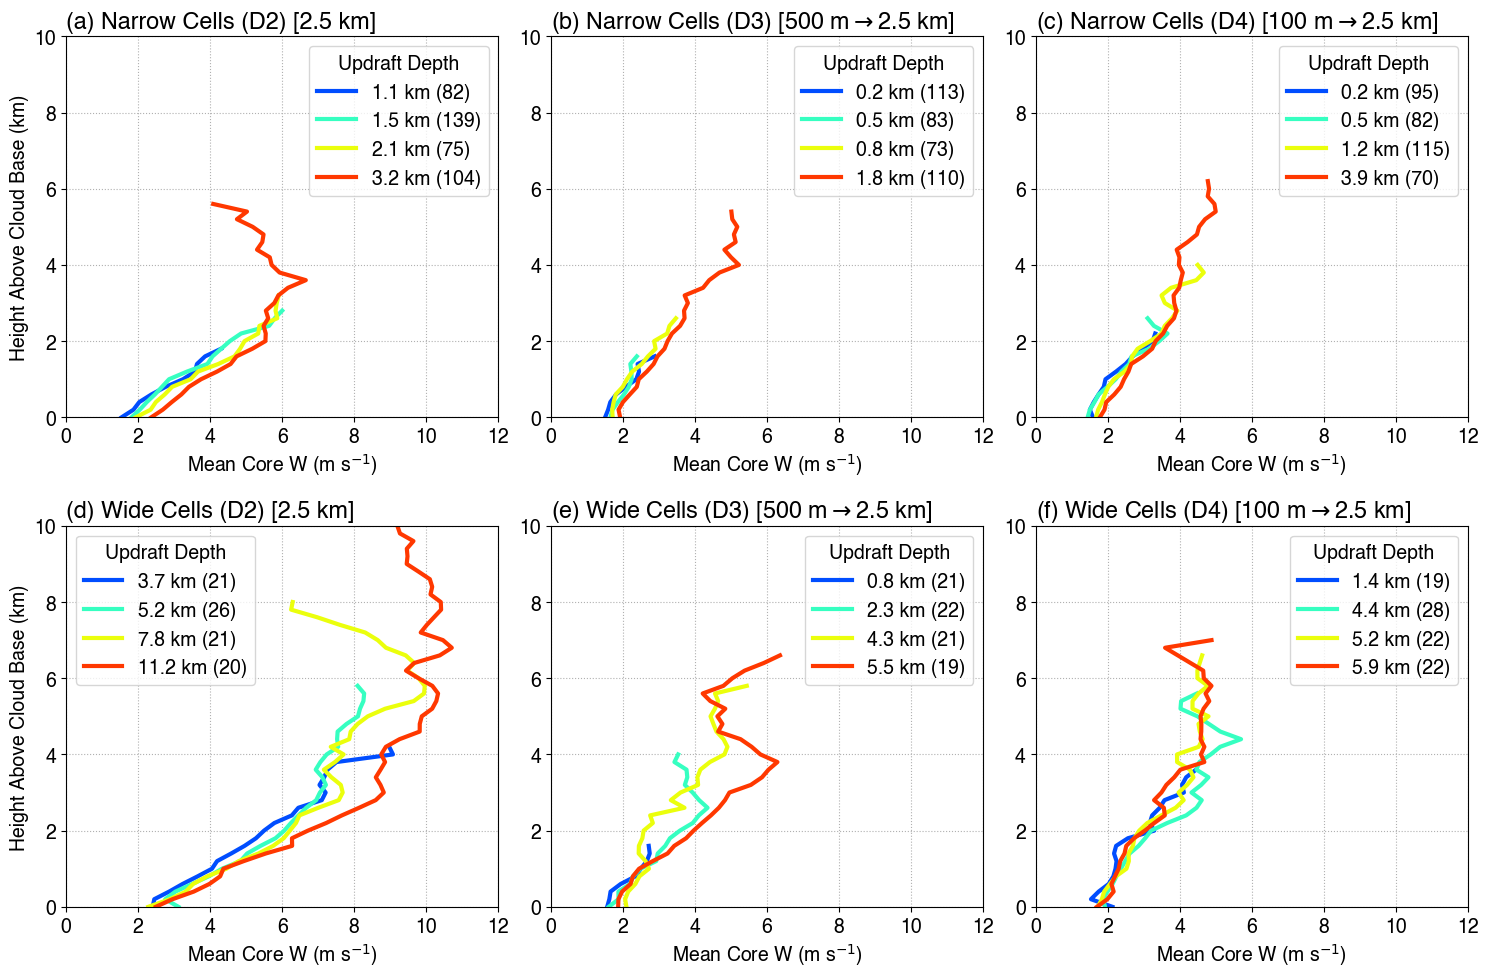

In [83]:
THRESH_w = 6
THRESH_n = 10
height_wbase = MaxCoreMeanW_n_avg_d2.z / 1000.
# Median profiles
med_w_d2 = MaxCoreMeanW_w_inqt_d2.sel(quantile=0.5).where(nsMaxCoreMeanW_w_d2 > THRESH_w)
med_w_d3 = MaxCoreMeanW_w_inqt_d3.sel(quantile=0.5).where(nsMaxCoreMeanW_w_d3 > THRESH_w)
med_w_d4 = MaxCoreMeanW_w_inqt_d4.sel(quantile=0.5).where(nsMaxCoreMeanW_w_d4 > THRESH_w)

med_n_d2 = MaxCoreMeanW_n_inqt_d2.sel(quantile=0.5).where(nsMaxCoreMeanW_n_d2 > THRESH_n)
med_n_d3 = MaxCoreMeanW_n_inqt_d3.sel(quantile=0.5).where(nsMaxCoreMeanW_n_d3 > THRESH_n)
med_n_d4 = MaxCoreMeanW_n_inqt_d4.sel(quantile=0.5).where(nsMaxCoreMeanW_n_d4 > THRESH_n)

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Mean Core W (m s$^{-1}$)']*ncol,
    ['Mean Core W (m s$^{-1}$)']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', r'(b) Narrow Cells (D3) [500 m$\rightarrow$2.5 km]', r'(c) Narrow Cells (D4) [100 m$\rightarrow$2.5 km]'],
    ['(d) Wide Cells (D2) [2.5 km]', r'(e) Wide Cells (D3) [500 m$\rightarrow$2.5 km]', r'(f) Wide Cells (D4) [100 m$\rightarrow$2.5 km]'],
]
ylims = (0,10)
xlims = [
    [(0,12)]*ncol,
    [(0,12)]*ncol,
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'best'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_CoreMeanW_d2_d3_d4.png'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, 
                     z_thresh=z_thresh, legend_show=legend_show, legend_loc=legend_loc, legend_text=legend_text, legend_ns=legend_ns, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/CIMax_CbaseProfile_NarrowWide_byETH_CoreMaxW_d2_d3_d4.png


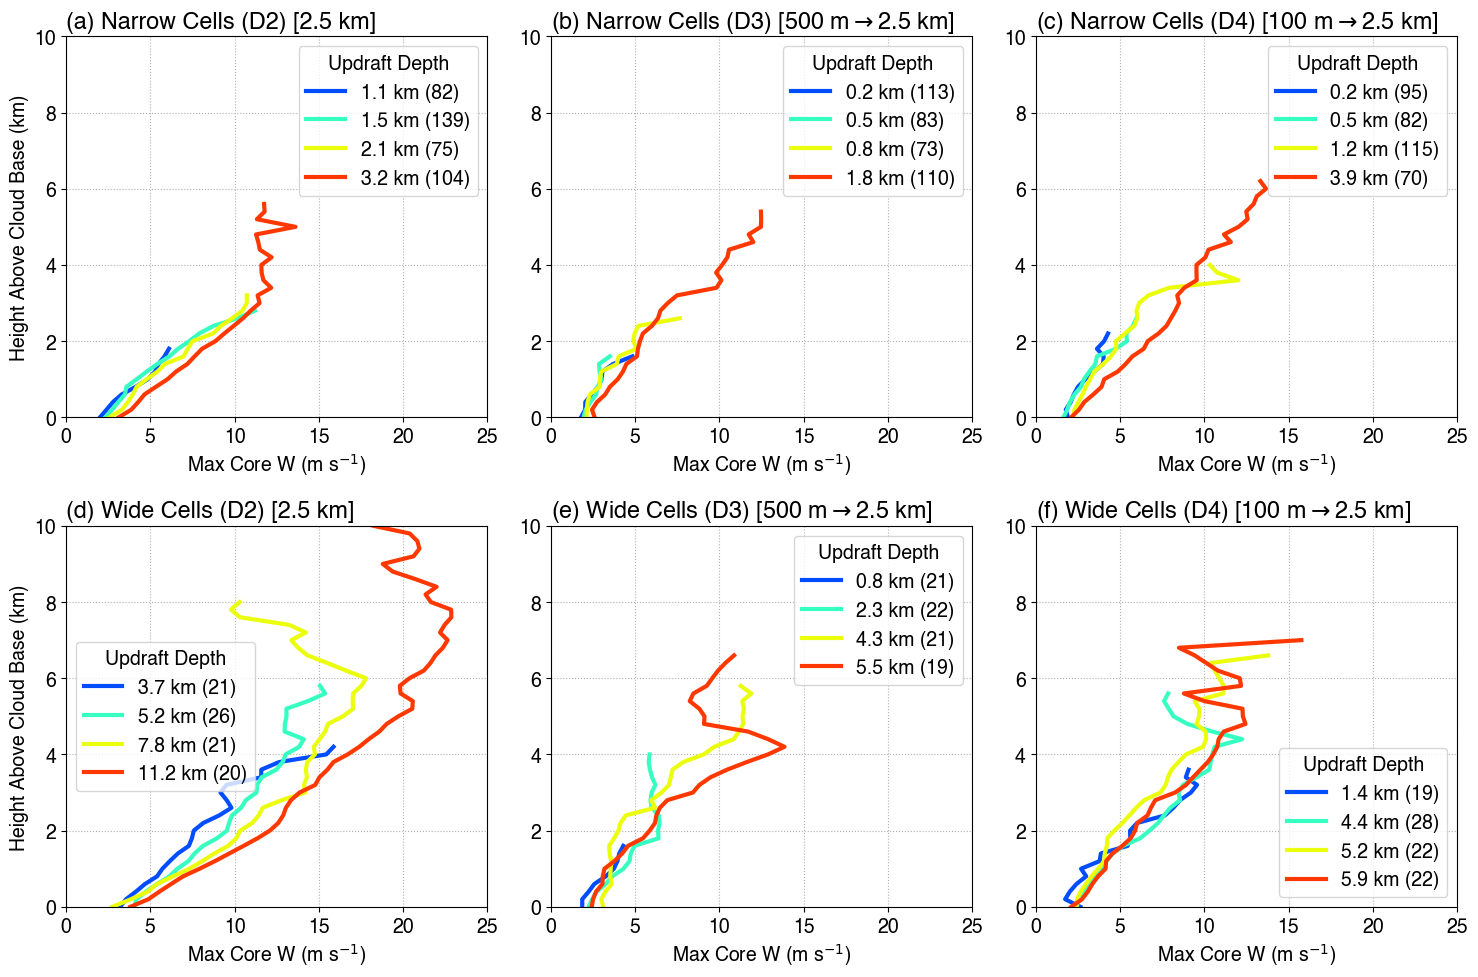

In [84]:
THRESH_w = 6
THRESH_n = 10
height_wbase = MaxCoreMaxW_n_avg_d2.z / 1000.
# Median profiles
med_w_d2 = MaxCoreMaxW_w_inqt_d2.sel(quantile=0.5).where(nsMaxCoreMaxW_w_d2 > THRESH_w)
med_w_d3 = MaxCoreMaxW_w_inqt_d3.sel(quantile=0.5).where(nsMaxCoreMaxW_w_d3 > THRESH_w)
med_w_d4 = MaxCoreMaxW_w_inqt_d4.sel(quantile=0.5).where(nsMaxCoreMaxW_w_d4 > THRESH_w)
med_n_d2 = MaxCoreMaxW_n_inqt_d2.sel(quantile=0.5).where(nsMaxCoreMaxW_n_d2 > THRESH_n)
med_n_d3 = MaxCoreMaxW_n_inqt_d3.sel(quantile=0.5).where(nsMaxCoreMaxW_n_d3 > THRESH_n)
med_n_d4 = MaxCoreMaxW_n_inqt_d4.sel(quantile=0.5).where(nsMaxCoreMaxW_n_d4 > THRESH_n)

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Max Core W (m s$^{-1}$)']*ncol,
    ['Max Core W (m s$^{-1}$)']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', r'(b) Narrow Cells (D3) [500 m$\rightarrow$2.5 km]', r'(c) Narrow Cells (D4) [100 m$\rightarrow$2.5 km]'],
    ['(d) Wide Cells (D2) [2.5 km]', r'(e) Wide Cells (D3) [500 m$\rightarrow$2.5 km]', r'(f) Wide Cells (D4) [100 m$\rightarrow$2.5 km]'],
]
ylims = (0,10)
xlims = [
    [(0,25)]*ncol,
    [(0,25)]*ncol,
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'best'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_CoreMaxW_d2_d3_d4.png'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, 
                     z_thresh=z_thresh, legend_show=legend_show, legend_loc=legend_loc, legend_text=legend_text, legend_ns=legend_ns, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/CIMax_CbaseProfile_NarrowWide_byETH_CoreMassFlux_d2_d3_d4.png


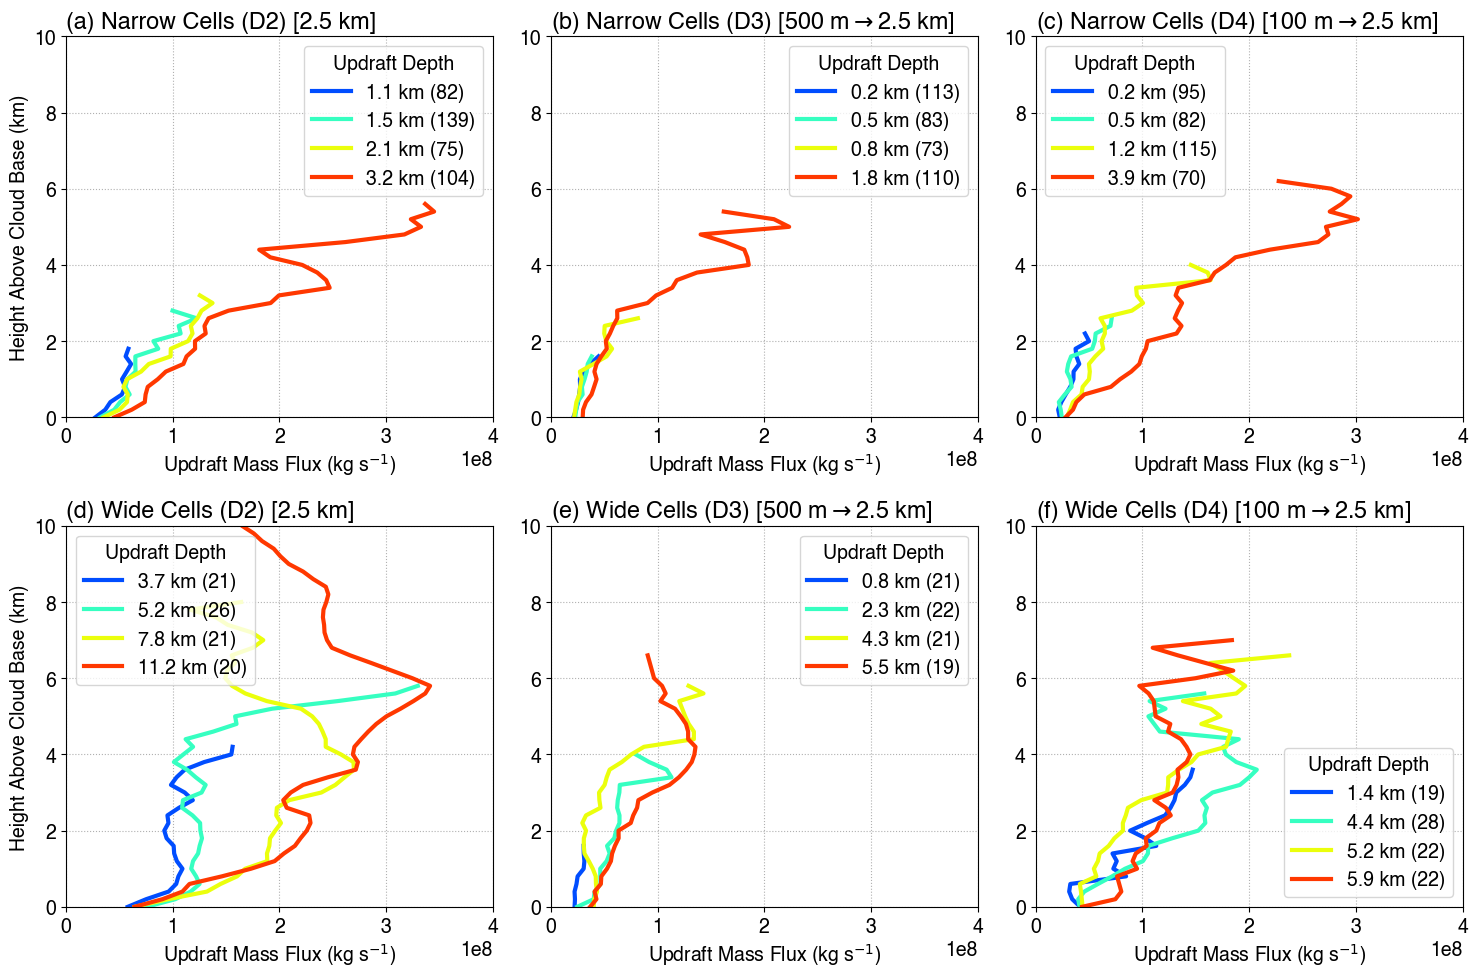

In [85]:
THRESH_w = 6
THRESH_n = 10
height_wbase = MaxCoreMassFlux_n_avg_d2.z / 1000.
# Median profiles
med_w_d2 = MaxCoreMassFlux_w_inqt_d2.sel(quantile=0.5).where(nsMaxCoreMassFlux_w_d2 > THRESH_w)
med_w_d3 = MaxCoreMassFlux_w_inqt_d3.sel(quantile=0.5).where(nsMaxCoreMassFlux_w_d3 > THRESH_w)
med_w_d4 = MaxCoreMassFlux_w_inqt_d4.sel(quantile=0.5).where(nsMaxCoreMassFlux_w_d4 > THRESH_w)

med_n_d2 = MaxCoreMassFlux_n_inqt_d2.sel(quantile=0.5).where(nsMaxCoreMassFlux_n_d2 > THRESH_n)
med_n_d3 = MaxCoreMassFlux_n_inqt_d3.sel(quantile=0.5).where(nsMaxCoreMassFlux_n_d3 > THRESH_n)
med_n_d4 = MaxCoreMassFlux_n_inqt_d4.sel(quantile=0.5).where(nsMaxCoreMassFlux_n_d4 > THRESH_n)

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Updraft Mass Flux (kg s$^{-1}$)']*ncol,
    ['Updraft Mass Flux (kg s$^{-1}$)']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', r'(b) Narrow Cells (D3) [500 m$\rightarrow$2.5 km]', r'(c) Narrow Cells (D4) [100 m$\rightarrow$2.5 km]'],
    ['(d) Wide Cells (D2) [2.5 km]', r'(e) Wide Cells (D3) [500 m$\rightarrow$2.5 km]', r'(f) Wide Cells (D4) [100 m$\rightarrow$2.5 km]'],
]
ylims = (0,10)
xlims = [
    [(0,4e8),(0,4e8),(0,4e8)],
    [(0,4e8),(0,4e8),(0,4e8)],
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'best'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_CoreMassFlux_d2_d3_d4.png'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, 
                     z_thresh=z_thresh, legend_show=legend_show, legend_loc=legend_loc, legend_text=legend_text, legend_ns=legend_ns, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/CIMax_CbaseProfile_NarrowWide_byETH_ShellMedianRH_d2_d3_d4.png


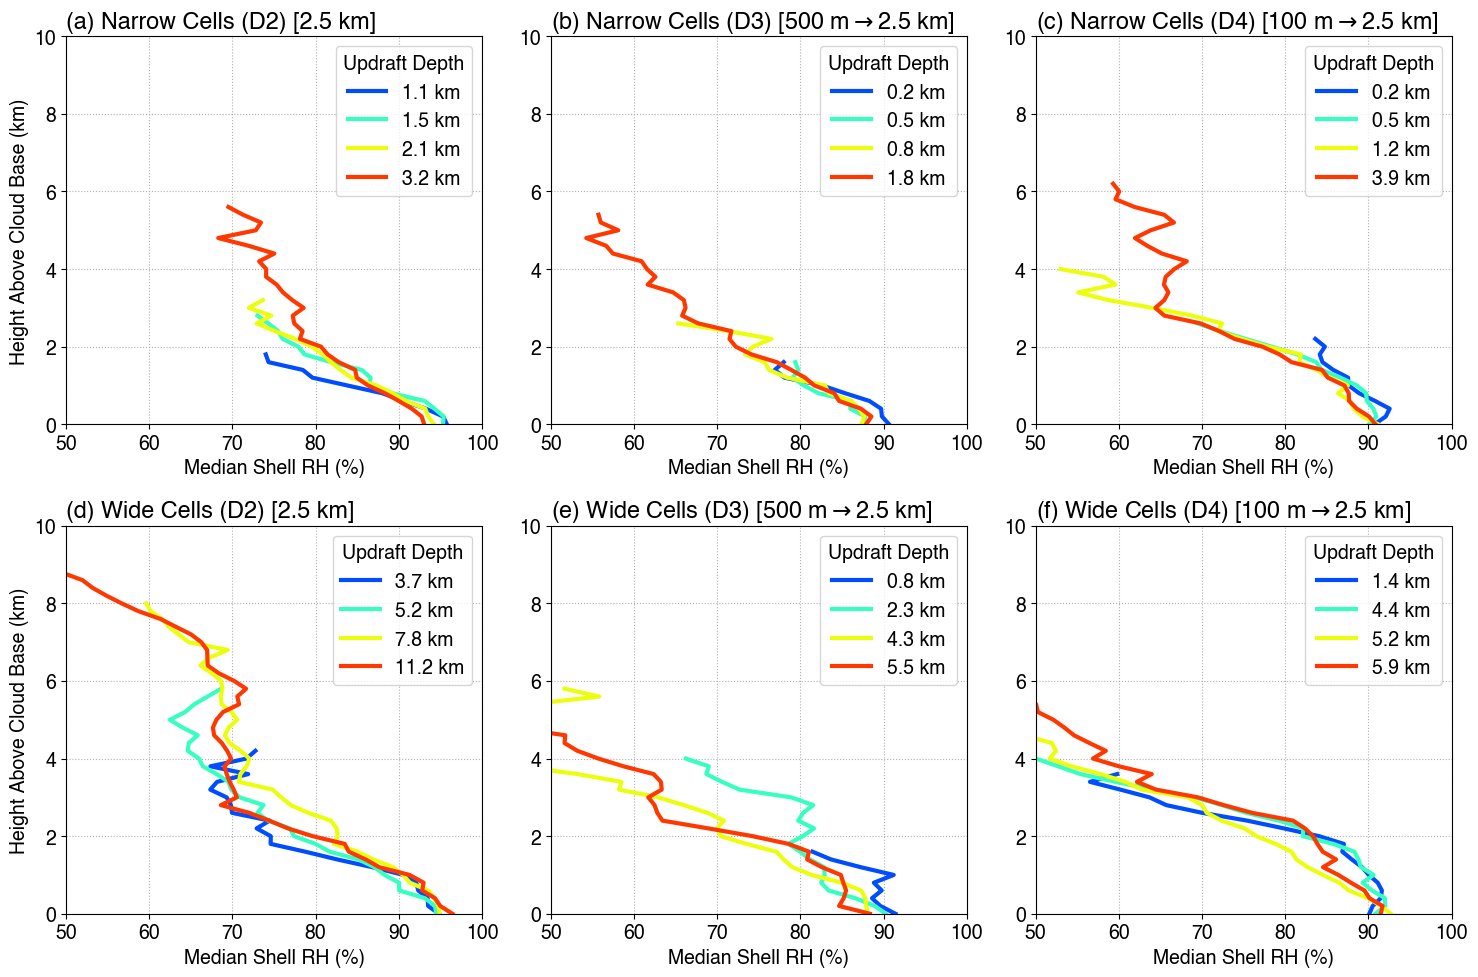

In [86]:
THRESH_w = 6
THRESH_n = 10
height_wbase = MedianShellRH_n_avg_d2.z / 1000.
# Median profiles
med_w_d2 = MedianShellRH_w_inqt_d2.sel(quantile=0.5).where(nsMedianShellRH_w_d2 > THRESH_w)
med_w_d3 = MedianShellRH_w_inqt_d3.sel(quantile=0.5).where(nsMedianShellRH_w_d3 > THRESH_w)
med_w_d4 = MedianShellRH_w_inqt_d4.sel(quantile=0.5).where(nsMedianShellRH_w_d4 > THRESH_w)

med_n_d2 = MedianShellRH_n_inqt_d2.sel(quantile=0.5).where(nsMedianShellRH_n_d2 > THRESH_n)
med_n_d3 = MedianShellRH_n_inqt_d3.sel(quantile=0.5).where(nsMedianShellRH_n_d3 > THRESH_n)
med_n_d4 = MedianShellRH_n_inqt_d4.sel(quantile=0.5).where(nsMedianShellRH_n_d4 > THRESH_n)

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Median Shell RH (%)']*ncol,
    ['Median Shell RH (%)']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', r'(b) Narrow Cells (D3) [500 m$\rightarrow$2.5 km]', r'(c) Narrow Cells (D4) [100 m$\rightarrow$2.5 km]'],
    ['(d) Wide Cells (D2) [2.5 km]', r'(e) Wide Cells (D3) [500 m$\rightarrow$2.5 km]', r'(f) Wide Cells (D4) [100 m$\rightarrow$2.5 km]'],
]
ylims = (0,10)
xlims = [
    [(50,100)]*ncol,
    [(50,100)]*ncol,
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'upper right'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_ShellMedianRH_d2_d3_d4.png'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, 
                     z_thresh=z_thresh, legend_show=legend_show, legend_loc=legend_loc, legend_text=legend_text, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

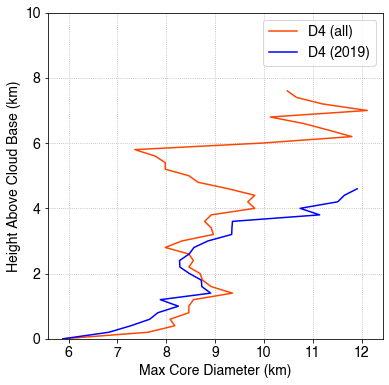

In [87]:
fig, ax = plt.subplots(figsize=(6,6))
THRESH_w = 5
med_w_d4 = MaxCoreDiam_w_inqt_d4.sel(quantile=0.5).where(nsMaxCoreDiam_w_d4 > THRESH_w).isel(ETH=3)
med_w_d4_2019 = MaxCoreDiam_w_inqt_d4_2019.sel(quantile=0.5).where(nsMaxCoreDiam_w_d4_2019> THRESH_w).isel(ETH=3)
ax.plot(med_w_d4, height_wbase, color='orangered', label='D4 (all)')
ax.plot(med_w_d4_2019, height_wbase, color='blue', label='D4 (2019)')
ax.legend()
ax.set_xlabel('Max Core Diameter (km)')
ax.set_ylabel('Height Above Cloud Base (km)')
ax.set_ylim(0, 10)
ax.grid(ls=':')